In [3]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import skew, kurtosis
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset successfully loaded.")
print("Dataset shape:", df.shape)

df.head()

Dataset successfully loaded.
Dataset shape: (23486, 11)


,no,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
required_columns = [
    "Rating",
    "Recommended IND"
]

segmentation_columns = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count"
]

missing_required_columns = [
    column for column in required_columns
    if column not in df.columns
]

missing_segmentation_columns = [
    column for column in segmentation_columns
    if column not in df.columns
]

if len(missing_required_columns) == 0:
    print("All required columns are available.")
else:
    print("Missing required columns:", missing_required_columns)

if len(missing_segmentation_columns) == 0:
    print("All GMM segmentation columns are available.")
else:
    print("Missing segmentation columns:", missing_segmentation_columns)

print("\nAvailable columns:")
print(df.columns.tolist())

All required columns are available.
All GMM segmentation columns are available.

Available columns:
['no', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [5]:
print("Dataset dimensions:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nRating values:")
print(df["Rating"].value_counts().sort_index())

print("\nRecommendation values:")
print(df["Recommended IND"].value_counts().sort_index())

Dataset dimensions: (23486, 11)

Data types:
no                         int64
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object

Missing values:
no                            0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Duplicate rows: 0

Rating values:
Rating
1      842
2     1565
3     2871
4     5077
5    13131
Name: count, dtype: int64

Recommendation values:
Recommended IND
0     4172
1    19314
Name: count

In [6]:
core_columns = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count"
]

df[core_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


In [7]:
invalid_rating = ~df["Rating"].between(1, 5)

invalid_recommendation = ~df["Recommended IND"].isin([0, 1])

invalid_age = df["Age"] <= 0

invalid_feedback = df["Positive Feedback Count"] < 0

validation_report = pd.DataFrame({
    "Check": [
        "Rating outside 1-5",
        "Recommendation outside 0-1",
        "Age less than or equal to 0",
        "Negative positive-feedback count"
    ],
    "Invalid Records": [
        invalid_rating.sum(),
        invalid_recommendation.sum(),
        invalid_age.sum(),
        invalid_feedback.sum()
    ]
})

validation_report

,Check,Invalid Records
0,Rating outside 1-5,0
1,Recommendation outside 0-1,0
2,Age less than or equal to 0,0
3,Negative positive-feedback count,0


In [8]:
quality_report = pd.DataFrame({
    "Column": core_columns,
    "Data Type": [df[column].dtype for column in core_columns],
    "Missing Values": [
        df[column].isna().sum()
        for column in core_columns
    ],
    "Unique Values": [
        df[column].nunique()
        for column in core_columns
    ]
})

print("Core column quality report:")
display(quality_report)

print("Exact duplicate rows:", df.duplicated().sum())

Core column quality report:


,Column,Data Type,Missing Values,Unique Values
0,Age,int64,0,77
1,Rating,int64,0,5
2,Recommended IND,int64,0,2
3,Positive Feedback Count,int64,0,82


Exact duplicate rows: 0


In [9]:
analysis_columns = [
    "Clothing ID",
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Division Name",
    "Department Name",
    "Class Name",
    "Review Text"
]

analysis_df = df[analysis_columns].copy()

category_columns = [
    "Division Name",
    "Department Name",
    "Class Name"
]

analysis_df[category_columns] = (
    analysis_df[category_columns]
    .fillna("Unknown")
)

print("Original dataset shape:", df.shape)
print("Analysis dataset shape:", analysis_df.shape)

analysis_df.head()

Original dataset shape: (23486, 11)
Analysis dataset shape: (23486, 9)


,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review Text
0,767,33,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and comf...
1,1080,34,5,1,4,General,Dresses,Dresses,Love this dress! it's sooo pretty. i happene...
2,1077,60,3,0,0,General,Dresses,Dresses,I had such high hopes for this dress and reall...
3,1049,50,5,1,0,General Petite,Bottoms,Pants,"I love, love, love this jumpsuit. it's fun, fl..."
4,847,47,5,1,6,General,Tops,Blouses,This shirt is very flattering to all due to th...


In [10]:
analysis_df["Review Length"] = (
    analysis_df["Review Text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

analysis_df[
    [
        "Review Text",
        "Review Length"
    ]
].head()

,Review Text,Review Length
0,Absolutely wonderful - silky and sexy and comf...,8
1,Love this dress! it's sooo pretty. i happene...,62
2,I had such high hopes for this dress and reall...,98
3,"I love, love, love this jumpsuit. it's fun, fl...",22
4,This shirt is very flattering to all due to th...,36


In [11]:
final_quality_check = pd.Series({
    "Total Records": len(analysis_df),
    "Missing Rating": analysis_df["Rating"].isna().sum(),
    "Missing Recommendation":
        analysis_df["Recommended IND"].isna().sum(),
    "Invalid Rating":
        (~analysis_df["Rating"].between(1, 5)).sum(),
    "Invalid Recommendation":
        (~analysis_df["Recommended IND"].isin([0, 1])).sum(),
    "Negative Feedback":
        (analysis_df["Positive Feedback Count"] < 0).sum(),
    "Missing Review Text":
        analysis_df["Review Text"].isna().sum()
})

print(final_quality_check)

Total Records             23486
Missing Rating                0
Missing Recommendation        0
Invalid Rating                0
Invalid Recommendation        0
Negative Feedback             0
Missing Review Text         845
dtype: int64


In [12]:
def distribution_summary(data, column):

    clean_data = data[column].dropna()

    summary = {
        "Column": column,
        "Count": clean_data.count(),
        "Mean": clean_data.mean(),
        "Median": clean_data.median(),
        "Mode": clean_data.mode().iloc[0],
        "Standard Deviation": clean_data.std(),
        "Variance": clean_data.var(),
        "Minimum": clean_data.min(),
        "Maximum": clean_data.max(),
        "Skewness": skew(clean_data),
        "Kurtosis": kurtosis(clean_data)
    }

    return summary

rating_summary = distribution_summary(
    analysis_df,
    "Rating"
)

recommendation_summary = distribution_summary(
    analysis_df,
    "Recommended IND"
)

distribution_report = pd.DataFrame([
    rating_summary,
    recommendation_summary
]).round(4)

distribution_report

,Column,Count,Mean,Median,Mode,Standard Deviation,Variance,Minimum,Maximum,Skewness,Kurtosis
0,Rating,23486,4.1960,5.0,5,1.1100,1.2322,1,5,-1.3134,0.8037
1,Recommended IND,23486,0.8224,1.0,1,0.3822,0.1461,0,1,-1.6868,0.8454


In [13]:
rating_distribution = (
    analysis_df["Rating"]
    .value_counts()
    .sort_index()
    .rename_axis("Rating")
    .reset_index(name="Frequency")
)

rating_distribution["Percentage"] = (
    rating_distribution["Frequency"]
    / rating_distribution["Frequency"].sum()
    * 100
).round(2)

rating_distribution

,Rating,Frequency,Percentage
0,1,842,3.59
1,2,1565,6.66
2,3,2871,12.22
3,4,5077,21.62
4,5,13131,55.91


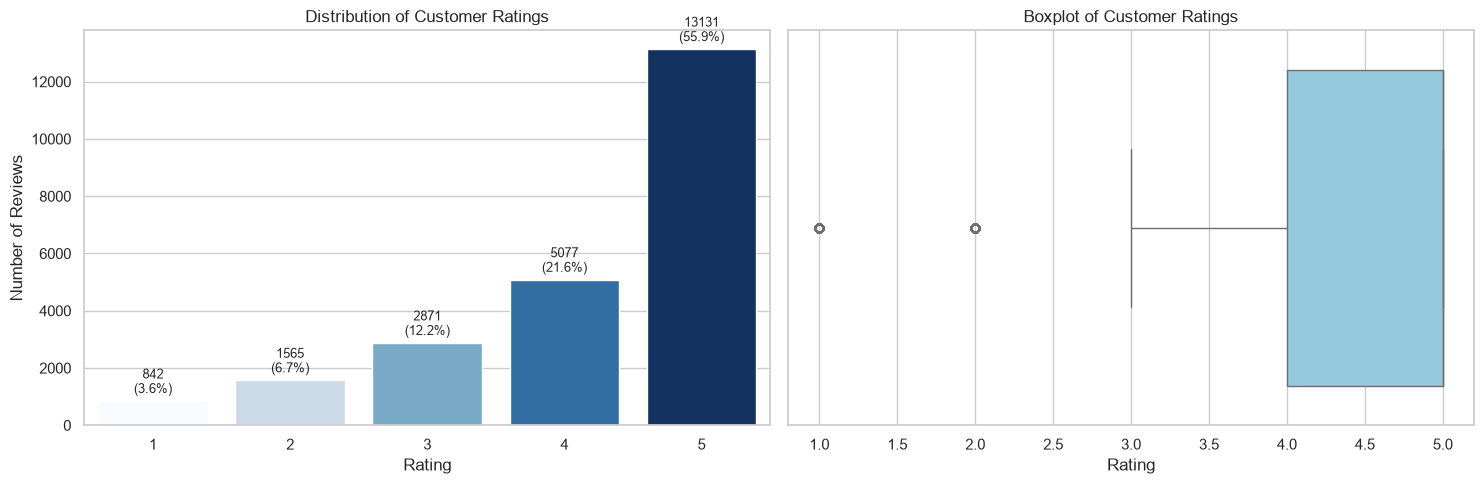

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(
    data=analysis_df,
    x="Rating",
    hue="Rating",
    palette="Blues",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Distribution of Customer Ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Reviews")

rating_counts = (
    analysis_df["Rating"]
    .value_counts()
    .sort_index()
)

total_ratings = rating_counts.sum()

for container in axes[0].containers:
    labels = [
        f"{bar.get_height():.0f}\n"
        f"({bar.get_height() / total_ratings * 100:.1f}%)"
        for bar in container
    ]

    axes[0].bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

sns.boxplot(
    data=analysis_df,
    x="Rating",
    color="skyblue",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Customer Ratings")
axes[1].set_xlabel("Rating")

plt.tight_layout()
plt.show()

In [15]:
recommendation_distribution = (
    analysis_df["Recommended IND"]
    .value_counts()
    .sort_index()
    .rename_axis("Recommended IND")
    .reset_index(name="Frequency")
)

recommendation_distribution["Status"] = (
    recommendation_distribution["Recommended IND"]
    .map({
        0: "Not Recommended",
        1: "Recommended"
    })
)

recommendation_distribution["Percentage"] = (
    recommendation_distribution["Frequency"]
    / recommendation_distribution["Frequency"].sum()
    * 100
).round(2)

recommendation_distribution[
    [
        "Recommended IND",
        "Status",
        "Frequency",
        "Percentage"
    ]
]

,Recommended IND,Status,Frequency,Percentage
0,0,Not Recommended,4172,17.76
1,1,Recommended,19314,82.24


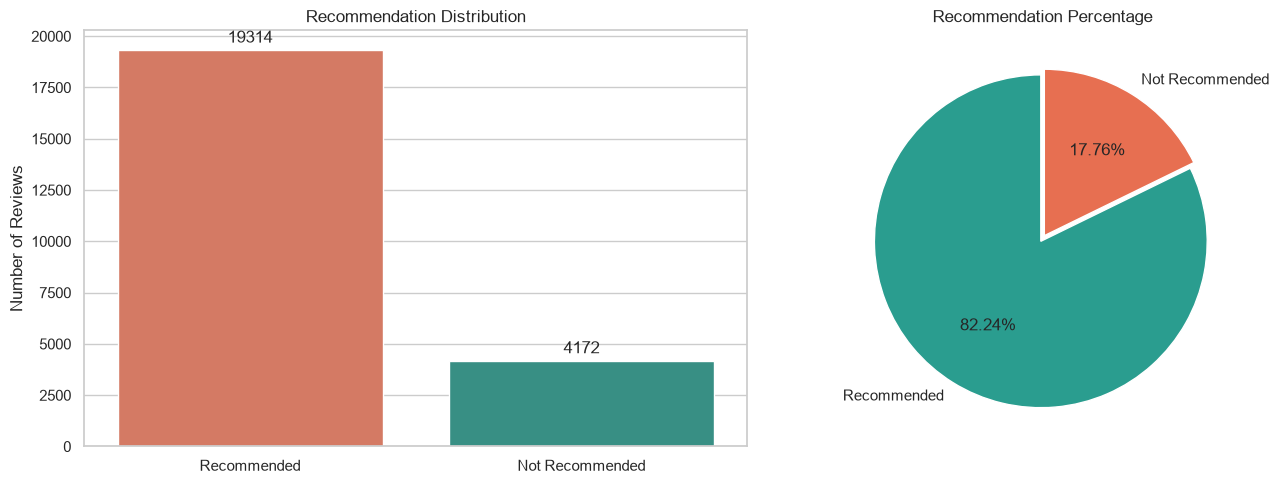

In [16]:
recommendation_plot_df = (
    analysis_df["Recommended IND"]
    .map({
        0: "Not Recommended",
        1: "Recommended"
    })
    .value_counts()
    .rename_axis("Recommendation Status")
    .reset_index(name="Frequency")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=recommendation_plot_df,
    x="Recommendation Status",
    y="Frequency",
    hue="Recommendation Status",
    palette=["#E76F51", "#2A9D8F"],
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Recommendation Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Reviews")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

axes[1].pie(
    recommendation_plot_df["Frequency"],
    labels=recommendation_plot_df["Recommendation Status"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["#2A9D8F", "#E76F51"],
    explode=(0.02, 0.02)
)

axes[1].set_title("Recommendation Percentage")

plt.tight_layout()
plt.show()

In [17]:
def create_rating_segment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

analysis_df["Rating Segment"] = (
    analysis_df["Rating"]
    .apply(create_rating_segment)
)

rating_segment_report = (
    analysis_df["Rating Segment"]
    .value_counts()
    .reindex(["Negative", "Neutral", "Positive"])
    .rename_axis("Rating Segment")
    .reset_index(name="Frequency")
)

rating_segment_report["Percentage"] = (
    rating_segment_report["Frequency"]
    / len(analysis_df)
    * 100
).round(2)

rating_segment_report

,Rating Segment,Frequency,Percentage
0,Negative,2407,10.25
1,Neutral,2871,12.22
2,Positive,18208,77.53


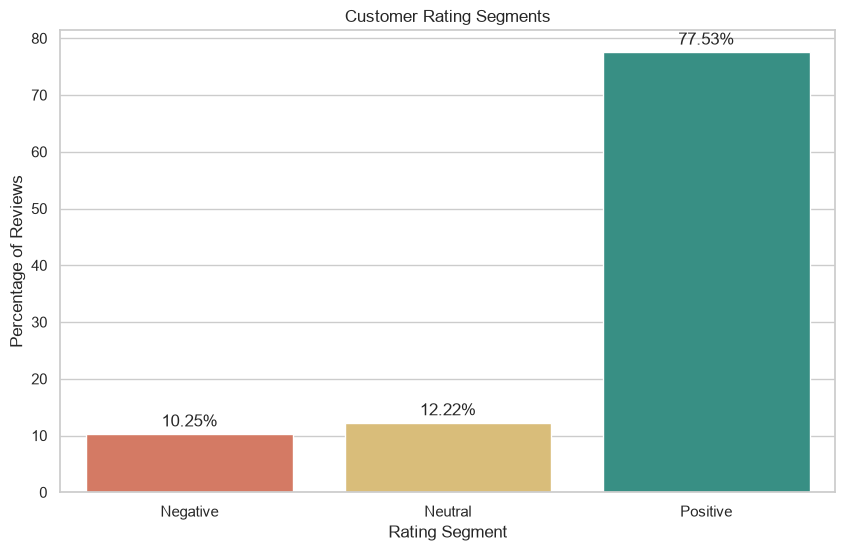

In [18]:
segment_colors = {
    "Negative": "#E76F51",
    "Neutral": "#E9C46A",
    "Positive": "#2A9D8F"
}

sns.barplot(
    data=rating_segment_report,
    x="Rating Segment",
    y="Percentage",
    hue="Rating Segment",
    palette=segment_colors,
    legend=False
)

plt.title("Customer Rating Segments")
plt.xlabel("Rating Segment")
plt.ylabel("Percentage of Reviews")

for container in plt.gca().containers:
    plt.gca().bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.show()

In [19]:
rating_recommendation_table = pd.crosstab(
    analysis_df["Rating"],
    analysis_df["Recommended IND"]
)

rating_recommendation_table.columns = [
    "Not Recommended",
    "Recommended"
]

rating_recommendation_table

,Not Recommended,Recommended
Rating,,
1,826,16
2,1471,94
3,1682,1189
4,168,4909
5,25,13106


In [20]:
rating_recommendation_percentage = pd.crosstab(
    analysis_df["Rating"],
    analysis_df["Recommended IND"],
    normalize="index"
).mul(100).round(2)

rating_recommendation_percentage.columns = [
    "Not Recommended %",
    "Recommended %"
]

rating_recommendation_percentage

,Not Recommended %,Recommended %
Rating,,
1,98.10,1.90
2,93.99,6.01
3,58.59,41.41
4,3.31,96.69
5,0.19,99.81


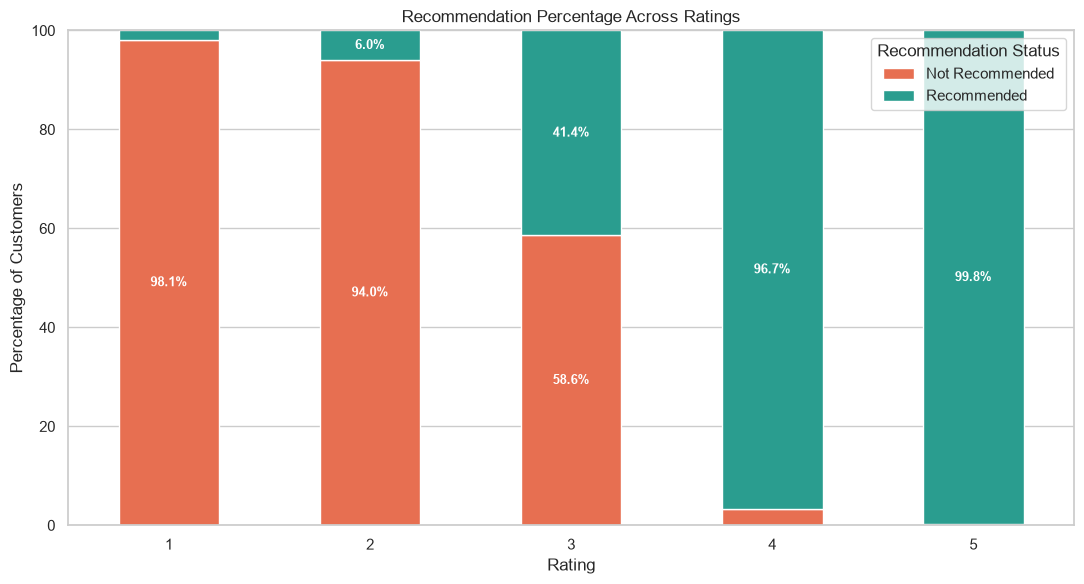

In [21]:
plot_data = pd.crosstab(
    analysis_df["Rating"],
    analysis_df["Recommended IND"],
    normalize="index"
).mul(100)

plot_data.columns = [
    "Not Recommended",
    "Recommended"
]

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["#E76F51", "#2A9D8F"]
)

plt.title("Recommendation Percentage Across Ratings")
plt.xlabel("Rating")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Recommendation Status")
plt.ylim(0, 100)

for container in ax.containers:
    labels = [
        f"{value:.1f}%"
        if value >= 5 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

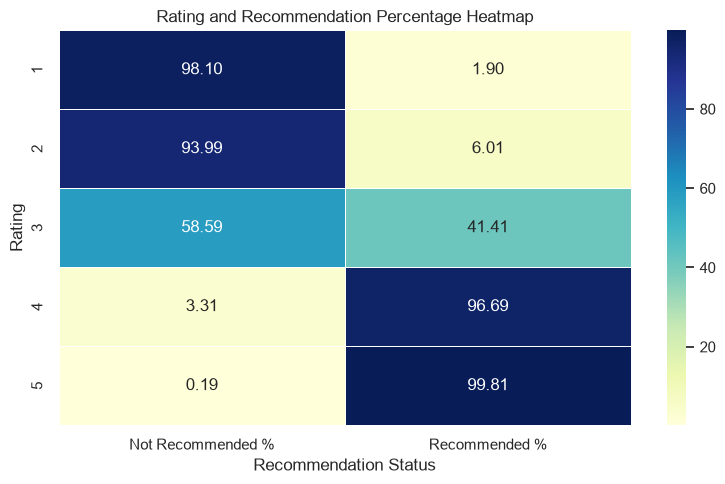

In [23]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    rating_recommendation_percentage,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Rating and Recommendation Percentage Heatmap")
plt.xlabel("Recommendation Status")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [24]:
contingency_table = pd.crosstab(
    analysis_df["Rating"],
    analysis_df["Recommended IND"]
)

chi_square, p_value, degrees_of_freedom, expected_frequency = (
    chi2_contingency(contingency_table)
)

print("Chi-square statistic:", round(chi_square, 4))
print("Degrees of freedom:", degrees_of_freedom)
print("P-value:", p_value)

if p_value < 0.05:
    print(
        "Conclusion: Reject H0. Rating and recommendation "
        "have a statistically significant association."
    )
else:
    print(
        "Conclusion: Fail to reject H0. A statistically "
        "significant association was not detected."
    )

Chi-square statistic: 16722.5032
Degrees of freedom: 4
P-value: 0.0
Conclusion: Reject H0. Rating and recommendation have a statistically significant association.


In [25]:
def calculate_cramers_v(contingency_table):

    chi2 = chi2_contingency(contingency_table)[0]
    total = contingency_table.to_numpy().sum()

    phi_squared = chi2 / total

    rows, columns = contingency_table.shape

    corrected_phi_squared = max(
        0,
        phi_squared
        - ((columns - 1) * (rows - 1)) / (total - 1)
    )

    corrected_rows = (
        rows - ((rows - 1) ** 2) / (total - 1)
    )

    corrected_columns = (
        columns - ((columns - 1) ** 2) / (total - 1)
    )

    denominator = min(
        corrected_columns - 1,
        corrected_rows - 1
    )

    return np.sqrt(
        corrected_phi_squared / denominator
    )

cramers_v = calculate_cramers_v(contingency_table)

print("Cramér's V:", round(cramers_v, 4))

Cramér's V: 0.8437


In [26]:
spearman_correlation, spearman_p_value = spearmanr(
    analysis_df["Rating"],
    analysis_df["Recommended IND"]
)

print(
    "Spearman correlation:",
    round(spearman_correlation, 4)
)

print(
    "Spearman p-value:",
    spearman_p_value
)

Spearman correlation: 0.6935
Spearman p-value: 0.0


In [27]:
high_rating_not_recommended = analysis_df[
    (analysis_df["Rating"] >= 4) &
    (analysis_df["Recommended IND"] == 0)
].copy()

low_rating_recommended = analysis_df[
    (analysis_df["Rating"] <= 2) &
    (analysis_df["Recommended IND"] == 1)
].copy()

contradiction_summary = pd.DataFrame({
    "Pattern": [
        "High rating but not recommended",
        "Low rating but recommended"
    ],
    "Number of Records": [
        len(high_rating_not_recommended),
        len(low_rating_recommended)
    ]
})

contradiction_summary["Dataset Percentage"] = (
    contradiction_summary["Number of Records"]
    / len(analysis_df)
    * 100
).round(3)

contradiction_summary

,Pattern,Number of Records,Dataset Percentage
0,High rating but not recommended,193,0.822
1,Low rating but recommended,110,0.468


In [28]:
total_contradictions = (
    len(high_rating_not_recommended)
    + len(low_rating_recommended)
)

print("Total contradictory records:", total_contradictions)

print(
    "Contradiction percentage:",
    round(
        total_contradictions / len(analysis_df) * 100,
        3
    ),
    "%"
)

Total contradictory records: 303
Contradiction percentage: 1.29 %


In [29]:
analysis_df["Contradiction Type"] = "Consistent Response"

analysis_df.loc[
    (analysis_df["Rating"] >= 4) &
    (analysis_df["Recommended IND"] == 0),
    "Contradiction Type"
] = "High Rating - Not Recommended"

analysis_df.loc[
    (analysis_df["Rating"] <= 2) &
    (analysis_df["Recommended IND"] == 1),
    "Contradiction Type"
] = "Low Rating - Recommended"

analysis_df["Is Contradiction"] = (
    analysis_df["Contradiction Type"]
    != "Consistent Response"
).astype(int)

analysis_df[
    [
        "Rating",
        "Recommended IND",
        "Contradiction Type",
        "Is Contradiction"
    ]
].head()

,Rating,Recommended IND,Contradiction Type,Is Contradiction
0,4,1,Consistent Response,0
1,5,1,Consistent Response,0
2,3,0,Consistent Response,0
3,5,1,Consistent Response,0
4,5,1,Consistent Response,0


In [30]:
gmm_source_columns = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Review Length"
]

print("Missing values before GMM preparation:")
print(
    analysis_df[gmm_source_columns]
    .isnull()
    .sum()
)

Missing values before GMM preparation:
Age                        0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Review Length              0
dtype: int64


In [31]:
original_skewness = (
    analysis_df[gmm_source_columns]
    .skew()
    .sort_values(ascending=False)
    .rename("Original Skewness")
)

original_skewness

Positive Feedback Count    6.472998
Age                        0.525615
Review Length             -0.088523
Rating                    -1.313529
Recommended IND           -1.686952
Name: Original Skewness, dtype: float64

In [32]:
gmm_df = analysis_df[
    gmm_source_columns
].copy()

gmm_df["Log Positive Feedback"] = np.log1p(
    gmm_df["Positive Feedback Count"]
)

gmm_df["Log Review Length"] = np.log1p(
    gmm_df["Review Length"]
)

gmm_df.head()

,Age,Rating,Recommended IND,Positive Feedback Count,Review Length,Log Positive Feedback,Log Review Length
0,33,4,1,0,8,0.000000,2.197225
1,34,5,1,4,62,1.609438,4.143135
2,60,3,0,0,98,0.000000,4.595120
3,50,5,1,0,22,0.000000,3.135494
4,47,5,1,6,36,1.945910,3.610918


In [33]:
transformation_comparison = pd.DataFrame({
    "Original Feature": [
        "Positive Feedback Count",
        "Review Length"
    ],
    "Original Skewness": [
        analysis_df["Positive Feedback Count"].skew(),
        analysis_df["Review Length"].skew()
    ],
    "Transformed Feature": [
        "Log Positive Feedback",
        "Log Review Length"
    ],
    "Transformed Skewness": [
        gmm_df["Log Positive Feedback"].skew(),
        gmm_df["Log Review Length"].skew()
    ]
}).round(4)

transformation_comparison

,Original Feature,Original Skewness,Transformed Feature,Transformed Skewness
0,Positive Feedback Count,6.4730,Log Positive Feedback,1.0872
1,Review Length,-0.0885,Log Review Length,-2.4817


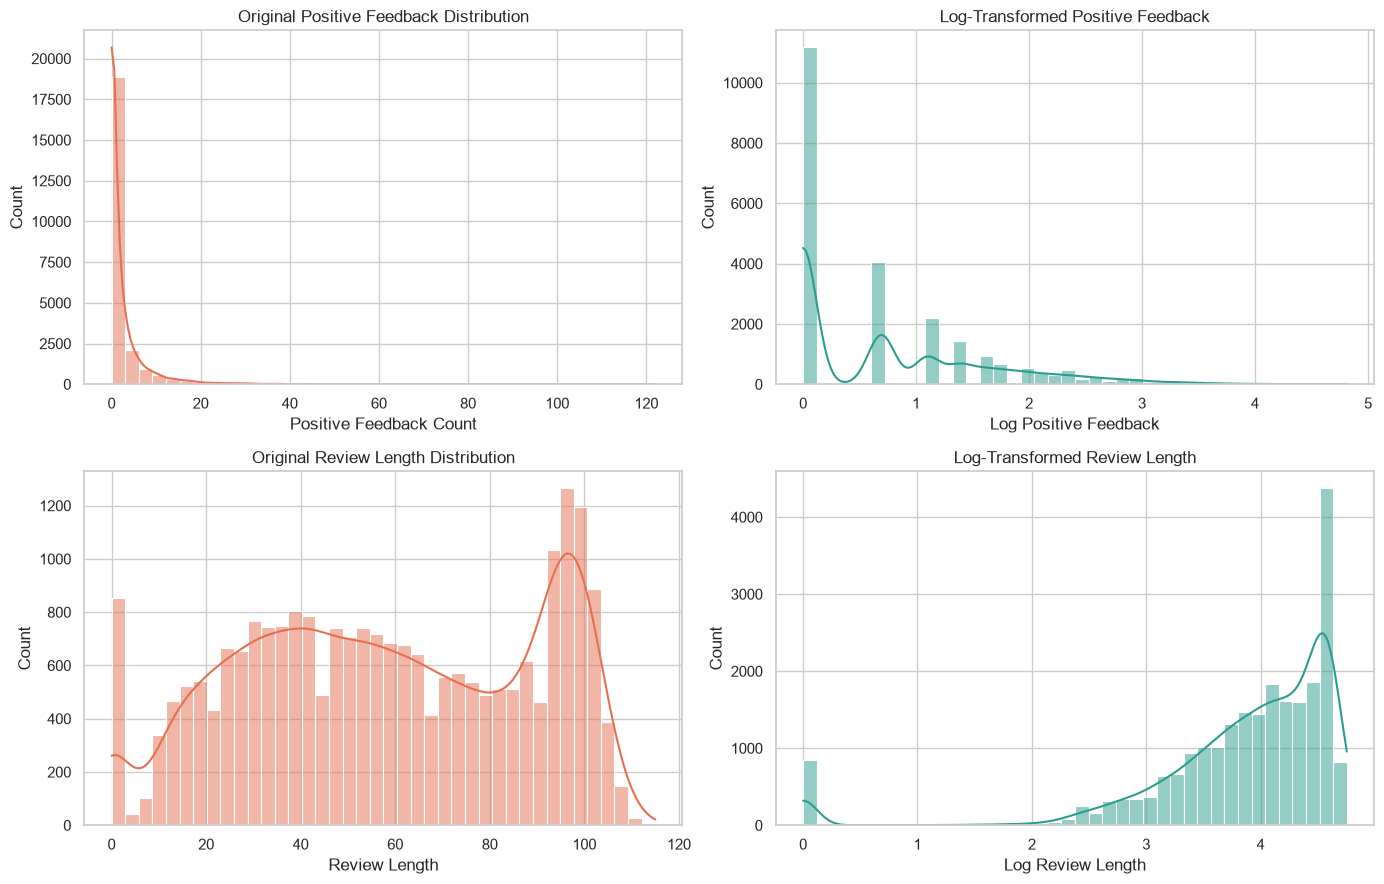

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(
    data=analysis_df,
    x="Positive Feedback Count",
    bins=40,
    kde=True,
    color="#E76F51",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Original Positive Feedback Distribution"
)

sns.histplot(
    data=gmm_df,
    x="Log Positive Feedback",
    bins=40,
    kde=True,
    color="#2A9D8F",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Log-Transformed Positive Feedback"
)

sns.histplot(
    data=analysis_df,
    x="Review Length",
    bins=40,
    kde=True,
    color="#E76F51",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Original Review Length Distribution"
)

sns.histplot(
    data=gmm_df,
    x="Log Review Length",
    bins=40,
    kde=True,
    color="#2A9D8F",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Log-Transformed Review Length"
)

plt.tight_layout()
plt.show()

In [35]:
gmm_features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Log Positive Feedback",
    "Log Review Length"
]

X_gmm = gmm_df[gmm_features].copy()

print("GMM feature matrix shape:", X_gmm.shape)
print("\nFeatures used:")
print(X_gmm.columns.tolist())

X_gmm.head()

GMM feature matrix shape: (23486, 5)

Features used:
['Age', 'Rating', 'Recommended IND', 'Log Positive Feedback', 'Log Review Length']


,Age,Rating,Recommended IND,Log Positive Feedback,Log Review Length
0,33,4,1,0.000000,2.197225
1,34,5,1,1.609438,4.143135
2,60,3,0,0.000000,4.595120
3,50,5,1,0.000000,3.135494
4,47,5,1,1.945910,3.610918


In [36]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_gmm)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=gmm_features,
    index=analysis_df.index
)

X_scaled_df.head()

,Age,Rating,Recommended IND,Log Positive Feedback,Log Review Length
0,-0.830549,-0.176604,0.464768,-0.837398,-1.734293
1,-0.749111,0.724291,0.464768,0.974587,0.336977
2,1.368277,-1.077499,-2.151612,-0.837398,0.818081
3,0.553897,0.724291,0.464768,-0.837398,-0.735578
4,0.309583,0.724291,0.464768,1.353404,-0.229526


In [37]:
scaling_report = pd.DataFrame({
    "Scaled Mean": X_scaled_df.mean(),
    "Scaled Standard Deviation": X_scaled_df.std(
        ddof=0
    ),
    "Scaled Minimum": X_scaled_df.min(),
    "Scaled Maximum": X_scaled_df.max()
}).round(4)

scaling_report

,Scaled Mean,Scaled Standard Deviation,Scaled Minimum,Scaled Maximum
Age,0.0,1.0,-2.0521,4.5444
Rating,0.0,1.0,-2.8793,0.7243
Recommended IND,0.0,1.0,-2.1516,0.4648
Log Positive Feedback,-0.0,1.0,-0.8374,4.5804
Log Review Length,0.0,1.0,-4.0731,0.9868


In [38]:
print(
    "Missing values in scaled data:",
    X_scaled_df.isnull().sum().sum()
)

print(
    "Infinite values in scaled data:",
    np.isinf(X_scaled_df.to_numpy()).sum()
)

print(
    "Number of records:",
    X_scaled_df.shape[0]
)

print(
    "Number of GMM features:",
    X_scaled_df.shape[1]
)

Missing values in scaled data: 0
Infinite values in scaled data: 0
Number of records: 23486
Number of GMM features: 5


In [39]:
cluster_range = range(2, 8)

covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

model_records = []
trained_models = {}

for covariance_type in covariance_types:

    for number_of_clusters in cluster_range:

        print(
            f"Training: clusters={number_of_clusters}, "
            f"covariance={covariance_type}"
        )

        gmm_model = GaussianMixture(
            n_components=number_of_clusters,
            covariance_type=covariance_type,
            random_state=42,
            n_init=3,
            max_iter=500,
            reg_covar=1e-5,
            init_params="kmeans"
        )

        gmm_model.fit(X_scaled)

        model_key = (
            number_of_clusters,
            covariance_type
        )

        trained_models[model_key] = gmm_model

        model_records.append({
            "Number of Clusters": number_of_clusters,
            "Covariance Type": covariance_type,
            "AIC": gmm_model.aic(X_scaled),
            "BIC": gmm_model.bic(X_scaled),
            "Converged": gmm_model.converged_,
            "Iterations": gmm_model.n_iter_
        })

print("All candidate models trained.")

Training: clusters=2, covariance=full
Training: clusters=3, covariance=full
Training: clusters=4, covariance=full
Training: clusters=5, covariance=full
Training: clusters=6, covariance=full
Training: clusters=7, covariance=full
Training: clusters=2, covariance=tied
Training: clusters=3, covariance=tied
Training: clusters=4, covariance=tied
Training: clusters=5, covariance=tied
Training: clusters=6, covariance=tied
Training: clusters=7, covariance=tied
Training: clusters=2, covariance=diag
Training: clusters=3, covariance=diag
Training: clusters=4, covariance=diag
Training: clusters=5, covariance=diag
Training: clusters=6, covariance=diag
Training: clusters=7, covariance=diag
Training: clusters=2, covariance=spherical
Training: clusters=3, covariance=spherical
Training: clusters=4, covariance=spherical
Training: clusters=5, covariance=spherical
Training: clusters=6, covariance=spherical
Training: clusters=7, covariance=spherical
All candidate models trained.


In [40]:
gmm_selection_report = pd.DataFrame(
    model_records
)

gmm_selection_report = (
    gmm_selection_report
    .sort_values("BIC")
    .reset_index(drop=True)
)

gmm_selection_report.head(10).round(2)

,Number of Clusters,Covariance Type,AIC,BIC,Converged,Iterations
0,7,full,-184466.84,-183289.48,True,19
1,7,diag,-173729.64,-173116.77,True,27
2,6,full,-168250.47,-167242.45,True,23
3,6,diag,-166919.02,-166394.85,True,27
4,5,full,-143992.23,-143153.55,True,17
5,5,diag,-142621.76,-142186.29,True,15
6,4,full,-76384.10,-75714.78,True,20
7,4,diag,-75007.14,-74660.38,True,13
8,3,full,-66126.42,-65626.44,True,11
9,3,diag,-65401.58,-65143.53,True,10


In [41]:
convergence_summary = (
    gmm_selection_report["Converged"]
    .value_counts()
    .rename_axis("Converged")
    .reset_index(name="Number of Models")
)

convergence_summary

,Converged,Number of Models
0,True,24


In [42]:
non_converged_models = gmm_selection_report[
    gmm_selection_report["Converged"] == False
]

if non_converged_models.empty:
    print("All GMM models converged successfully.")
else:
    print("Some models did not converge:")
    display(non_converged_models)

All GMM models converged successfully.


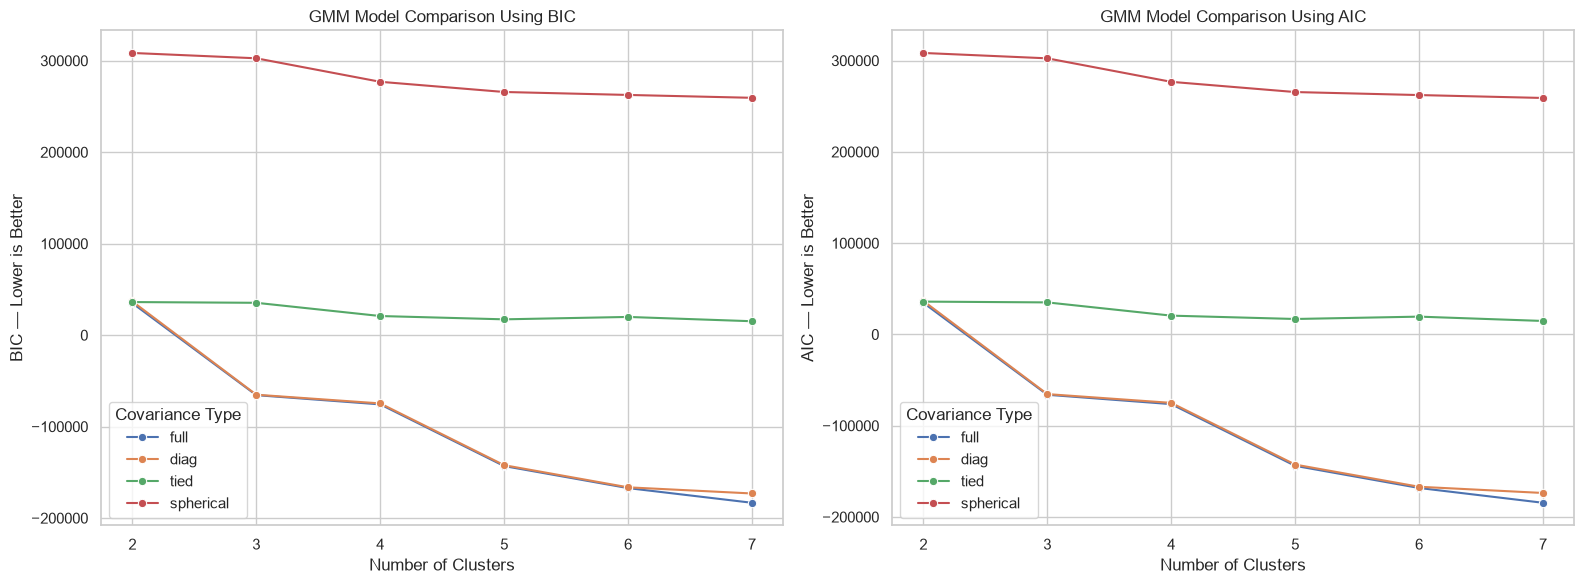

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=gmm_selection_report,
    x="Number of Clusters",
    y="BIC",
    hue="Covariance Type",
    marker="o",
    ax=axes[0]
)

axes[0].set_title(
    "GMM Model Comparison Using BIC"
)
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("BIC — Lower is Better")

sns.lineplot(
    data=gmm_selection_report,
    x="Number of Clusters",
    y="AIC",
    hue="Covariance Type",
    marker="o",
    ax=axes[1]
)

axes[1].set_title(
    "GMM Model Comparison Using AIC"
)
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("AIC — Lower is Better")

plt.tight_layout()
plt.show()

In [44]:
best_model_per_cluster_count = (
    gmm_selection_report
    .sort_values("BIC")
    .groupby(
        "Number of Clusters",
        as_index=False
    )
    .first()
    .sort_values("Number of Clusters")
)

best_model_per_cluster_count[
    [
        "Number of Clusters",
        "Covariance Type",
        "AIC",
        "BIC",
        "Converged"
    ]
].round(2)

,Number of Clusters,Covariance Type,AIC,BIC,Converged
0,2,full,34611.93,34942.56,True
1,3,full,-66126.42,-65626.44,True
2,4,full,-76384.10,-75714.78,True
3,5,full,-143992.23,-143153.55,True
4,6,full,-168250.47,-167242.45,True
5,7,full,-184466.84,-183289.48,True


In [45]:
rng = np.random.default_rng(42)

silhouette_sample_size = min(
    4000,
    len(X_scaled)
)

sample_indices = rng.choice(
    len(X_scaled),
    size=silhouette_sample_size,
    replace=False
)

X_silhouette_sample = X_scaled[
    sample_indices
]

silhouette_values = []

for _, model_row in (
    best_model_per_cluster_count.iterrows()
):

    number_of_clusters = int(
        model_row["Number of Clusters"]
    )

    covariance_type = model_row[
        "Covariance Type"
    ]

    model_key = (
        number_of_clusters,
        covariance_type
    )

    candidate_model = trained_models[model_key]

    sample_labels = candidate_model.predict(
        X_silhouette_sample
    )

    if len(np.unique(sample_labels)) > 1:
        score = silhouette_score(
            X_silhouette_sample,
            sample_labels
        )
    else:
        score = np.nan

    silhouette_values.append(score)

best_model_per_cluster_count[
    "Silhouette Score"
] = silhouette_values

best_model_per_cluster_count[
    [
        "Number of Clusters",
        "Covariance Type",
        "AIC",
        "BIC",
        "Silhouette Score"
    ]
].round(4)

,Number of Clusters,Covariance Type,AIC,BIC,Silhouette Score
0,2,full,34611.9265,34942.5571,0.4362
1,3,full,-66126.4187,-65626.4408,0.2486
2,4,full,-76384.1030,-75714.7777,0.2694
3,5,full,-143992.2272,-143153.5546,0.2386
4,6,full,-168250.4735,-167242.4536,0.2162
5,7,full,-184466.8448,-183289.4774,0.1934


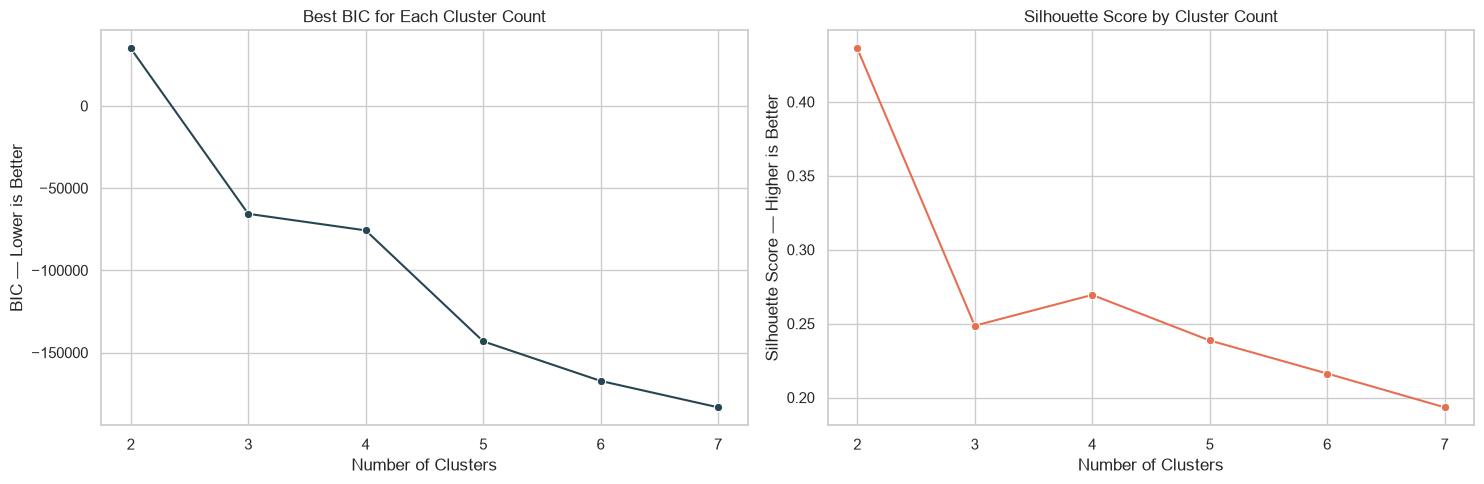

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=best_model_per_cluster_count,
    x="Number of Clusters",
    y="BIC",
    marker="o",
    color="#264653",
    ax=axes[0]
)

axes[0].set_title(
    "Best BIC for Each Cluster Count"
)
axes[0].set_ylabel("BIC — Lower is Better")

sns.lineplot(
    data=best_model_per_cluster_count,
    x="Number of Clusters",
    y="Silhouette Score",
    marker="o",
    color="#E76F51",
    ax=axes[1]
)

axes[1].set_title(
    "Silhouette Score by Cluster Count"
)
axes[1].set_ylabel(
    "Silhouette Score — Higher is Better"
)

plt.tight_layout()
plt.show()

In [47]:
valid_models = gmm_selection_report[
    gmm_selection_report["Converged"] == True
].copy()

best_model_row = valid_models.loc[
    valid_models["BIC"].idxmin()
]

best_number_of_clusters = int(
    best_model_row["Number of Clusters"]
)

best_covariance_type = best_model_row[
    "Covariance Type"
]

best_model_key = (
    best_number_of_clusters,
    best_covariance_type
)

best_gmm = trained_models[best_model_key]

print(
    "Selected number of clusters:",
    best_number_of_clusters
)

print(
    "Selected covariance type:",
    best_covariance_type
)

print(
    "Selected model AIC:",
    round(best_model_row["AIC"], 2)
)

print(
    "Selected model BIC:",
    round(best_model_row["BIC"], 2)
)

Selected number of clusters: 7
Selected covariance type: full
Selected model AIC: -184466.84
Selected model BIC: -183289.48


In [48]:
cluster_labels = best_gmm.predict(
    X_scaled
)

cluster_probabilities = best_gmm.predict_proba(
    X_scaled
)

analysis_df["GMM Cluster"] = (
    cluster_labels + 1
)

analysis_df["Cluster Confidence"] = (
    cluster_probabilities.max(axis=1)
)

analysis_df["Cluster Uncertainty"] = (
    1 - analysis_df["Cluster Confidence"]
)

print("Cluster assignments completed.")

analysis_df[
    [
        "Age",
        "Rating",
        "Recommended IND",
        "Positive Feedback Count",
        "Review Length",
        "GMM Cluster",
        "Cluster Confidence",
        "Cluster Uncertainty"
    ]
].head()

Cluster assignments completed.


,Age,Rating,Recommended IND,Positive Feedback Count,Review Length,GMM Cluster,Cluster Confidence,Cluster Uncertainty
0,33,4,1,0,8,1,0.989294,1.070624e-02
1,34,5,1,4,62,5,1.000000,2.454925e-12
2,60,3,0,0,98,2,0.999085,9.153889e-04
3,50,5,1,0,22,1,0.750073,2.499266e-01
4,47,5,1,6,36,5,1.000000,6.608047e-13


In [49]:
cluster_size_report = (
    analysis_df["GMM Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("GMM Cluster")
    .reset_index(name="Number of Records")
)

cluster_size_report["Percentage"] = (
    cluster_size_report["Number of Records"]
    / len(analysis_df)
    * 100
).round(2)

cluster_size_report

,GMM Cluster,Number of Records,Percentage
0,1,8560,36.45
1,2,1632,6.95
2,3,2467,10.50
3,4,845,3.60
4,5,6791,28.92
5,6,2469,10.51
6,7,722,3.07


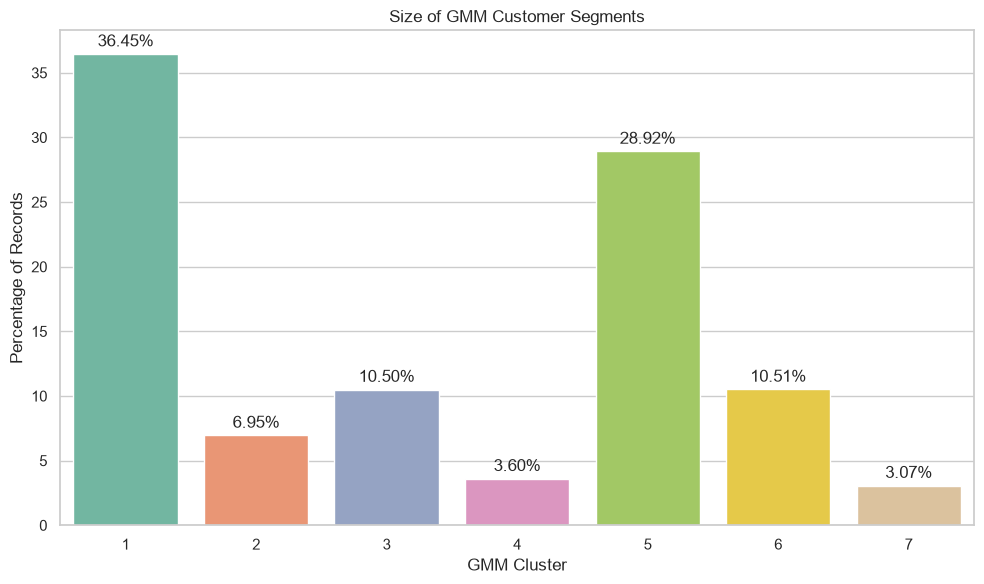

In [50]:
sns.barplot(
    data=cluster_size_report,
    x="GMM Cluster",
    y="Percentage",
    hue="GMM Cluster",
    palette="Set2",
    legend=False
)

plt.title("Size of GMM Customer Segments")
plt.xlabel("GMM Cluster")
plt.ylabel("Percentage of Records")

for container in plt.gca().containers:
    plt.gca().bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [51]:
confidence_summary = (
    analysis_df["Cluster Confidence"]
    .describe()
    .round(4)
)

confidence_summary

count    23486.0000
mean         0.9118
std          0.1419
min          0.5001
25%          0.8905
50%          1.0000
75%          1.0000
max          1.0000
Name: Cluster Confidence, dtype: float64

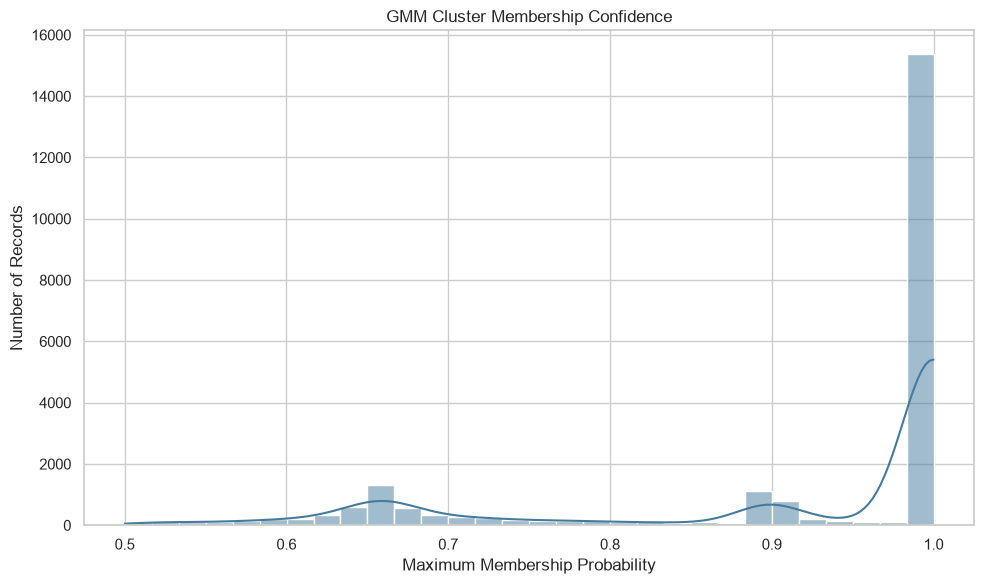

In [52]:
sns.histplot(
    data=analysis_df,
    x="Cluster Confidence",
    bins=30,
    kde=True,
    color="#457B9D"
)

plt.title("GMM Cluster Membership Confidence")
plt.xlabel("Maximum Membership Probability")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [53]:
cluster_profile = (
    analysis_df
    .groupby("GMM Cluster")
    .agg(
        Records=("GMM Cluster", "size"),
        Average_Age=("Age", "mean"),
        Average_Rating=("Rating", "mean"),
        Recommendation_Rate=(
            "Recommended IND",
            "mean"
        ),
        Average_Positive_Feedback=(
            "Positive Feedback Count",
            "mean"
        ),
        Median_Positive_Feedback=(
            "Positive Feedback Count",
            "median"
        ),
        Average_Review_Length=(
            "Review Length",
            "mean"
        ),
        Average_Confidence=(
            "Cluster Confidence",
            "mean"
        ),
        Contradiction_Rate=(
            "Is Contradiction",
            "mean"
        )
    )
    .reset_index()
)

cluster_profile["Percentage"] = (
    cluster_profile["Records"]
    / len(analysis_df)
    * 100
)

cluster_profile["Recommendation_Rate"] *= 100
cluster_profile["Contradiction_Rate"] *= 100

cluster_profile = cluster_profile[
    [
        "GMM Cluster",
        "Records",
        "Percentage",
        "Average_Age",
        "Average_Rating",
        "Recommendation_Rate",
        "Average_Positive_Feedback",
        "Median_Positive_Feedback",
        "Average_Review_Length",
        "Average_Confidence",
        "Contradiction_Rate"
    ]
]

cluster_profile.round(2)

,GMM Cluster,Records,Percentage,Average_Age,Average_Rating,Recommendation_Rate,Average_Positive_Feedback,Median_Positive_Feedback,Average_Review_Length,Average_Confidence,Contradiction_Rate
0,1,8560,36.45,42.06,4.60,100.0,0.00,0.0,52.74,0.77,0.56
1,2,1632,6.95,41.82,2.32,0.0,0.00,0.0,56.85,1.00,4.53
2,3,2467,10.50,43.68,4.00,100.0,4.74,2.0,68.74,1.00,0.00
3,4,845,3.60,41.01,4.53,91.6,0.00,0.0,0.00,1.00,0.83
4,5,6791,28.92,45.16,5.00,100.0,4.44,2.0,64.37,0.99,0.00
5,6,2469,10.51,42.75,2.29,0.0,5.72,3.0,65.41,1.00,4.58
6,7,722,3.07,43.72,2.90,100.0,5.01,3.0,69.94,1.00,8.45


In [54]:
def assign_segment_name(row):
    rating = row["Average_Rating"]
    recommendation = row["Recommendation_Rate"]

    if rating >= 4.5 and recommendation >= 90:
        return "Highly Satisfied Recommenders"

    elif rating >= 4.0 and recommendation >= 75:
        return "Satisfied Recommenders"

    elif rating <= 2.5 and recommendation < 30:
        return "Dissatisfied Non-Recommenders"

    elif rating < 3.5 and recommendation >= 50:
        return "Critical but Recommending"

    elif rating >= 4.0 and recommendation < 50:
        return "Positive but Non-Recommending"

    else:
        return "Mixed or Uncertain Customers"

cluster_profile["Segment Name"] = (
    cluster_profile.apply(
        assign_segment_name,
        axis=1
    )
)

cluster_profile[
    [
        "GMM Cluster",
        "Segment Name",
        "Records",
        "Percentage",
        "Average_Rating",
        "Recommendation_Rate",
        "Contradiction_Rate"
    ]
].round(2)

,GMM Cluster,Segment Name,Records,Percentage,Average_Rating,Recommendation_Rate,Contradiction_Rate
0,1,Highly Satisfied Recommenders,8560,36.45,4.60,100.0,0.56
1,2,Dissatisfied Non-Recommenders,1632,6.95,2.32,0.0,4.53
2,3,Satisfied Recommenders,2467,10.50,4.00,100.0,0.00
3,4,Highly Satisfied Recommenders,845,3.60,4.53,91.6,0.83
4,5,Highly Satisfied Recommenders,6791,28.92,5.00,100.0,0.00
5,6,Dissatisfied Non-Recommenders,2469,10.51,2.29,0.0,4.58
6,7,Critical but Recommending,722,3.07,2.90,100.0,8.45


In [55]:
segment_name_mapping = dict(
    zip(
        cluster_profile["GMM Cluster"],
        cluster_profile["Segment Name"]
    )
)

analysis_df["Segment Name"] = (
    analysis_df["GMM Cluster"]
    .map(segment_name_mapping)
)

analysis_df[
    [
        "Rating",
        "Recommended IND",
        "GMM Cluster",
        "Segment Name",
        "Cluster Confidence"
    ]
].head()

,Rating,Recommended IND,GMM Cluster,Segment Name,Cluster Confidence
0,4,1,1,Highly Satisfied Recommenders,0.989294
1,5,1,5,Highly Satisfied Recommenders,1.000000
2,3,0,2,Dissatisfied Non-Recommenders,0.999085
3,5,1,1,Highly Satisfied Recommenders,0.750073
4,5,1,5,Highly Satisfied Recommenders,1.000000


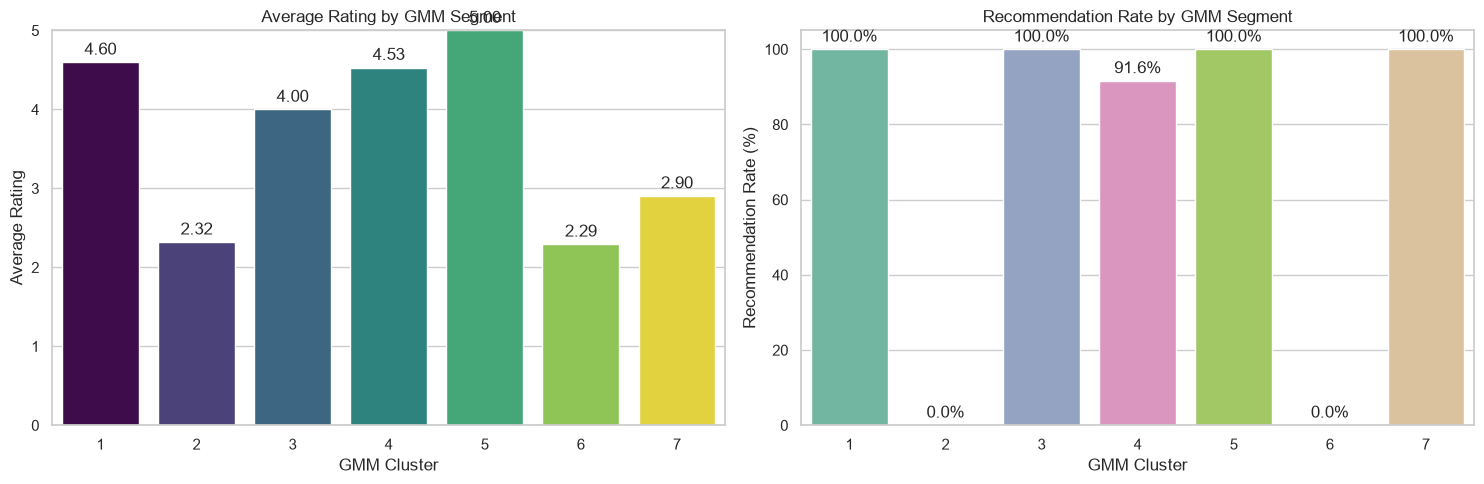

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=cluster_profile,
    x="GMM Cluster",
    y="Average_Rating",
    hue="GMM Cluster",
    palette="viridis",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Average Rating by GMM Segment")
axes[0].set_xlabel("GMM Cluster")
axes[0].set_ylabel("Average Rating")
axes[0].set_ylim(0, 5)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

sns.barplot(
    data=cluster_profile,
    x="GMM Cluster",
    y="Recommendation_Rate",
    hue="GMM Cluster",
    palette="Set2",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Recommendation Rate by GMM Segment"
)
axes[1].set_xlabel("GMM Cluster")
axes[1].set_ylabel("Recommendation Rate (%)")
axes[1].set_ylim(0, 105)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

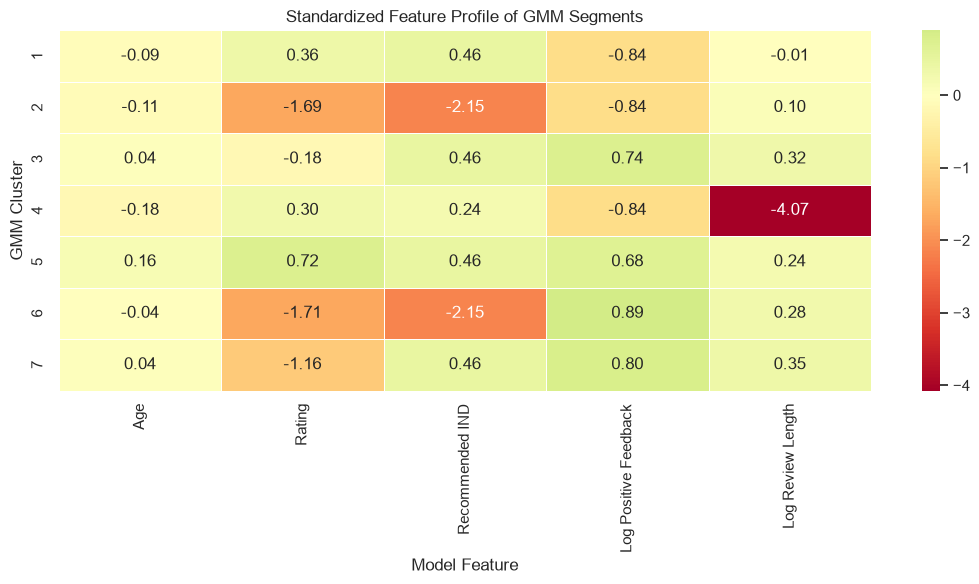

In [57]:
standardized_cluster_data = (
    X_scaled_df.copy()
)

standardized_cluster_data["GMM Cluster"] = (
    analysis_df["GMM Cluster"].values
)

standardized_cluster_profile = (
    standardized_cluster_data
    .groupby("GMM Cluster")
    .mean()
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    standardized_cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title("Standardized Feature Profile of GMM Segments")
plt.xlabel("Model Feature")
plt.ylabel("GMM Cluster")
plt.tight_layout()
plt.show()

In [58]:
cluster_rating_distribution = pd.crosstab(
    analysis_df["GMM Cluster"],
    analysis_df["Rating"],
    normalize="index"
).mul(100).round(2)

cluster_rating_distribution

Rating,1,2,3,4,5
GMM Cluster,,,,,
1,0.08,0.48,5.95,26.60,66.89
2,19.30,34.74,41.42,3.80,0.74
3,0.00,0.00,0.00,100.00,0.00
4,2.49,1.89,5.68,20.00,69.94
5,0.00,0.00,0.00,0.00,100.00
6,19.89,35.97,39.57,4.13,0.45
7,1.11,7.34,91.55,0.00,0.00


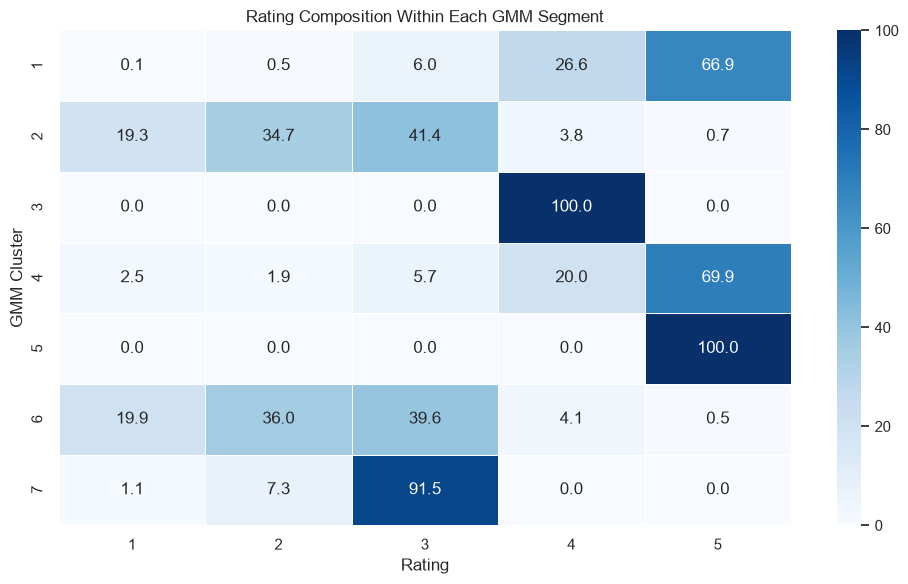

In [59]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_rating_distribution,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Rating Composition Within Each GMM Segment")
plt.xlabel("Rating")
plt.ylabel("GMM Cluster")
plt.tight_layout()
plt.show()

In [60]:
age_bins = [
    17,
    29,
    39,
    49,
    59,
    69,
    np.inf
]

age_labels = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70+"
]

analysis_df["Age Group"] = pd.cut(
    analysis_df["Age"],
    bins=age_bins,
    labels=age_labels
)

cluster_age_distribution = pd.crosstab(
    analysis_df["GMM Cluster"],
    analysis_df["Age Group"],
    normalize="index"
).mul(100).round(2)

cluster_age_distribution

Age Group,18-29,30-39,40-49,50-59,60-69,70+
GMM Cluster,,,,,,
1,14.25,34.09,25.88,16.12,8.69,0.97
2,14.64,33.82,28.06,14.40,7.48,1.59
3,10.78,32.31,27.44,17.59,10.17,1.70
4,10.89,42.13,26.51,13.49,5.80,1.18
5,10.93,29.47,24.78,18.41,12.80,3.62
6,11.75,34.59,27.30,16.00,8.30,2.07
7,11.36,31.02,27.15,19.39,9.00,2.08


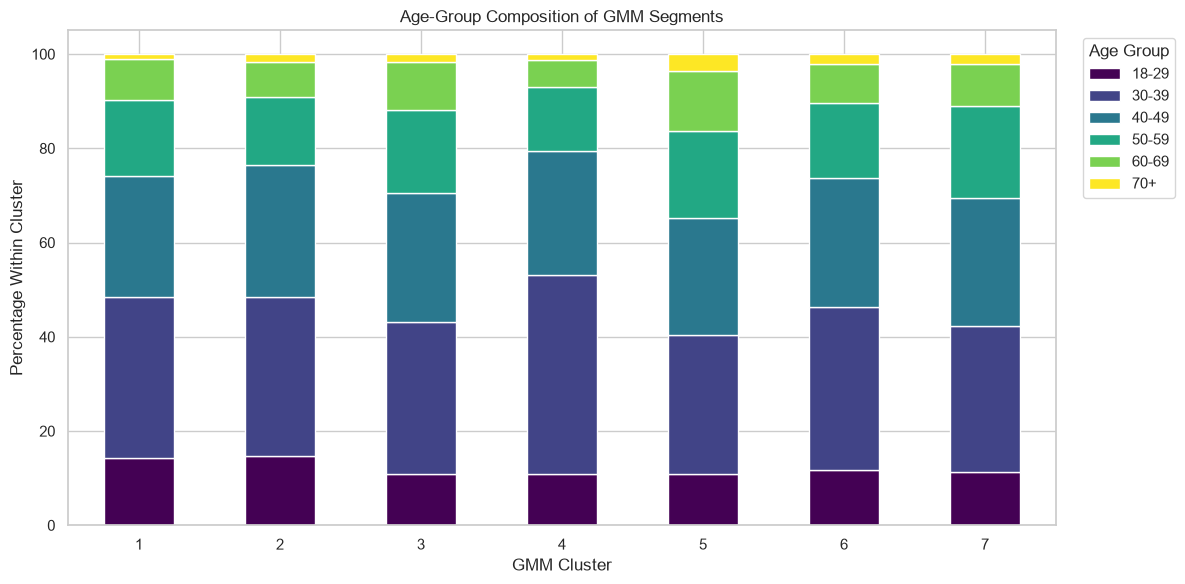

In [61]:
cluster_age_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="viridis"
)

plt.title("Age-Group Composition of GMM Segments")
plt.xlabel("GMM Cluster")
plt.ylabel("Percentage Within Cluster")
plt.xticks(rotation=0)
plt.legend(
    title="Age Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [62]:
department_cluster_distribution = pd.crosstab(
    analysis_df["GMM Cluster"],
    analysis_df["Department Name"],
    normalize="index"
).mul(100).round(2)

department_cluster_distribution

Department Name,Bottoms,Dresses,Intimate,Jackets,Tops,Trend,Unknown
GMM Cluster,,,,,,,
1,16.47,25.61,7.65,4.11,45.76,0.28,0.12
2,13.85,26.96,6.68,3.49,48.84,0.18,0.00
3,16.25,28.33,7.46,4.54,42.64,0.77,0.00
4,16.21,20.59,9.70,3.55,49.70,0.12,0.12
5,17.35,27.08,7.77,5.04,42.11,0.60,0.04
6,13.16,30.66,5.87,4.46,44.75,1.09,0.00
7,16.90,30.19,4.43,4.02,43.91,0.55,0.00


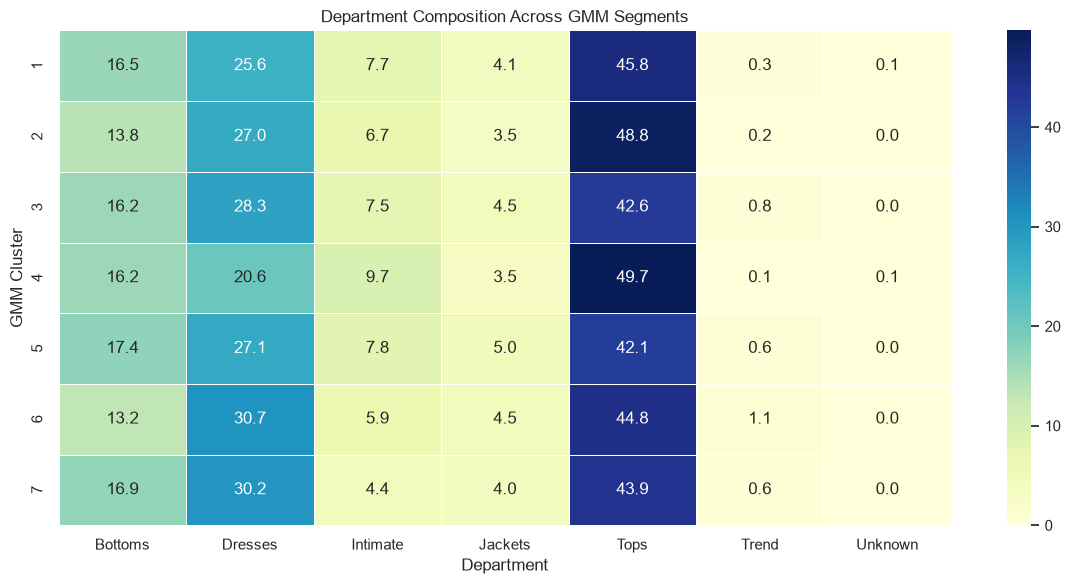

In [63]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    department_cluster_distribution,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Department Composition Across GMM Segments")
plt.xlabel("Department")
plt.ylabel("GMM Cluster")
plt.tight_layout()
plt.show()

In [64]:
top_department_by_cluster = (
    analysis_df
    .groupby(
        [
            "GMM Cluster",
            "Department Name"
        ]
    )
    .size()
    .reset_index(name="Records")
    .sort_values(
        [
            "GMM Cluster",
            "Records"
        ],
        ascending=[True, False]
    )
    .groupby("GMM Cluster")
    .head(1)
    .reset_index(drop=True)
)

top_department_by_cluster

,GMM Cluster,Department Name,Records
0,1,Tops,3917
1,2,Tops,797
2,3,Tops,1052
3,4,Tops,420
4,5,Tops,2860
5,6,Tops,1105
6,7,Tops,317


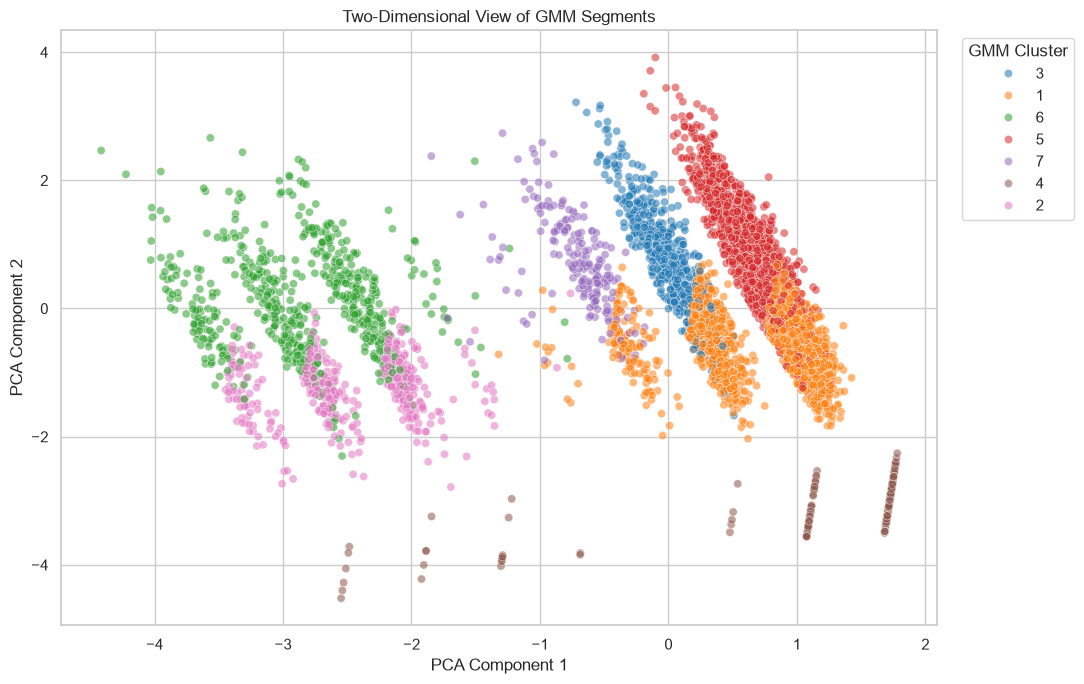

Variance represented by two PCA components: 61.77 %


In [65]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_plot_df = pd.DataFrame({
    "PCA Component 1": X_pca[:, 0],
    "PCA Component 2": X_pca[:, 1],
    "GMM Cluster": analysis_df[
        "GMM Cluster"
    ].astype(str).values
})

pca_sample_size = min(
    6000,
    len(pca_plot_df)
)

pca_plot_sample = pca_plot_df.sample(
    n=pca_sample_size,
    random_state=42
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_plot_sample,
    x="PCA Component 1",
    y="PCA Component 2",
    hue="GMM Cluster",
    palette="tab10",
    alpha=0.55,
    s=35
)

plt.title("Two-Dimensional View of GMM Segments")
plt.legend(
    title="GMM Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

print(
    "Variance represented by two PCA components:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

In [66]:
gmm_log_density = best_gmm.score_samples(
    X_scaled
)

analysis_df["GMM Log Density"] = (
    gmm_log_density
)

analysis_df["GMM Log Density"].describe()

count    23486.000000
mean         3.933383
std          2.851012
min        -19.791222
25%          3.511511
50%          4.950076
75%          5.824911
max          6.704073
Name: GMM Log Density, dtype: float64

In [67]:
density_threshold = analysis_df[
    "GMM Log Density"
].quantile(0.01)

analysis_df["Density Anomaly"] = (
    analysis_df["GMM Log Density"]
    <= density_threshold
).astype(int)

print(
    "Density anomaly threshold:",
    round(density_threshold, 4)
)

print(
    "Density anomalies:",
    analysis_df["Density Anomaly"].sum()
)

Density anomaly threshold: -4.7401
Density anomalies: 235


In [69]:
confidence_threshold = 0.70

analysis_df["Low Confidence Anomaly"] = (
    analysis_df["Cluster Confidence"]
    < confidence_threshold
).astype(int)

print(
    "Records with cluster confidence below 0.70:",
    analysis_df["Low Confidence Anomaly"].sum()
)

Records with cluster confidence below 0.70: 4084


In [70]:
def calculate_iqr_bounds(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    return q1, q3, lower_bound, upper_bound

In [71]:
extreme_columns = [
    "Age",
    "Positive Feedback Count",
    "Review Length"
]

iqr_records = []

for column in extreme_columns:
    q1, q3, lower_bound, upper_bound = (
        calculate_iqr_bounds(
            analysis_df,
            column
        )
    )

    iqr_records.append({
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound
    })

iqr_report = pd.DataFrame(
    iqr_records
).round(2)

iqr_report

,Feature,Q1,Q3,Lower Bound,Upper Bound
0,Age,34.0,52.0,7.0,79.0
1,Positive Feedback Count,0.0,3.0,-4.5,7.5
2,Review Length,34.0,87.0,-45.5,166.5


In [72]:
for column in extreme_columns:
    q1, q3, lower_bound, upper_bound = (
        calculate_iqr_bounds(
            analysis_df,
            column
        )
    )

    indicator_name = (
        column
        .replace(" ", "_")
        + "_Extreme"
    )

    analysis_df[indicator_name] = (
        (analysis_df[column] < lower_bound) |
        (analysis_df[column] > upper_bound)
    ).astype(int)

In [73]:
extreme_indicator_columns = [
    "Age_Extreme",
    "Positive_Feedback_Count_Extreme",
    "Review_Length_Extreme"
]

analysis_df["Extreme Feature Count"] = (
    analysis_df[extreme_indicator_columns]
    .sum(axis=1)
)

analysis_df[
    [
        "Age",
        "Positive Feedback Count",
        "Review Length",
        "Extreme Feature Count"
    ]
].head()

,Age,Positive Feedback Count,Review Length,Extreme Feature Count
0,33,0,8,0
1,34,4,62,0
2,60,0,98,0
3,50,0,22,0
4,47,6,36,0


In [74]:
analysis_df["Density Rarity Score"] = (
    analysis_df["GMM Log Density"]
    .rank(
        method="average",
        ascending=False,
        pct=True
    )
)

In [75]:
analysis_df["Anomaly Score"] = (
    0.50
    * analysis_df["Density Rarity Score"]

    + 0.20
    * analysis_df["Cluster Uncertainty"]

    + 0.20
    * analysis_df["Is Contradiction"]

    + 0.10
    * (
        analysis_df["Extreme Feature Count"]
        / len(extreme_indicator_columns)
    )
)

In [76]:
composite_threshold = analysis_df[
    "Anomaly Score"
].quantile(0.99)

print(
    "Composite anomaly threshold:",
    round(composite_threshold, 4)
)

Composite anomaly threshold: 0.6297


In [77]:
analysis_df["Final Anomaly"] = (
    (analysis_df["Anomaly Score"]
     >= composite_threshold)

    | (analysis_df["Density Anomaly"] == 1)

    | (analysis_df["Is Contradiction"] == 1)

    | (analysis_df["Extreme Feature Count"] >= 2)
).astype(int)

print(
    "Total anomalies detected:",
    analysis_df["Final Anomaly"].sum()
)

print(
    "Anomaly percentage:",
    round(
        analysis_df["Final Anomaly"].mean()
        * 100,
        2
    ),
    "%"
)

Total anomalies detected: 467
Anomaly percentage: 1.99 %


In [78]:
def identify_anomaly_type(row):
    anomaly_types = []

    if row["Density Anomaly"] == 1:
        anomaly_types.append(
            "Low GMM Density"
        )

    if row["Low Confidence Anomaly"] == 1:
        anomaly_types.append(
            "Low Cluster Confidence"
        )

    if row["Is Contradiction"] == 1:
        anomaly_types.append(
            "Rating-Recommendation Contradiction"
        )

    if row["Extreme Feature Count"] >= 2:
        anomaly_types.append(
            "Multiple Numerical Extremes"
        )

    if (
        row["Anomaly Score"]
        >= composite_threshold
        and len(anomaly_types) == 0
    ):
        anomaly_types.append(
            "High Composite Score"
        )

    if len(anomaly_types) == 0:
        return "Normal"

    return " | ".join(anomaly_types)

analysis_df["Anomaly Type"] = (
    analysis_df.apply(
        identify_anomaly_type,
        axis=1
    )
)

In [79]:
anomaly_type_report = (
    analysis_df.loc[
        analysis_df["Final Anomaly"] == 1,
        "Anomaly Type"
    ]
    .value_counts()
    .rename_axis("Anomaly Type")
    .reset_index(name="Records")
)

anomaly_type_report

,Anomaly Type,Records
0,Rating-Recommendation Contradiction,222
1,Low GMM Density,151
2,Low GMM Density | Rating-Recommendation Contra...,81
3,Multiple Numerical Extremes,10
4,Low GMM Density | Multiple Numerical Extremes,3


In [80]:
anomaly_df = (
    analysis_df[
        analysis_df["Final Anomaly"] == 1
    ]
    .copy()
    .sort_values(
        "Anomaly Score",
        ascending=False
    )
)

anomaly_display_columns = [
    "Clothing ID",
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Review Length",
    "Department Name",
    "GMM Cluster",
    "Segment Name",
    "Cluster Confidence",
    "GMM Log Density",
    "Anomaly Score",
    "Anomaly Type",
    "Review Text"
]

anomaly_df[
    anomaly_display_columns
].head(20)

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Review Length,Department Name,GMM Cluster,Segment Name,Cluster Confidence,GMM Log Density,Anomaly Score,Anomaly Type,Review Text
16428,867,56,1,1,12,25,Tops,7,Critical but Recommending,1.000000,-19.279045,0.733291,Low GMM Density | Rating-Recommendation Contra...,"Love this top! it's pretty, unique and well ma..."
1616,1059,85,2,1,2,55,Bottoms,7,Critical but Recommending,1.000000,-9.571708,0.732865,Low GMM Density | Rating-Recommendation Contra...,Unique print but not great execution. the pant...
20689,864,39,2,1,42,93,Tops,7,Critical but Recommending,1.000000,-9.267656,0.732780,Low GMM Density | Rating-Recommendation Contra...,I ordered these in both colors. the red is muc...
11636,939,64,5,0,23,96,Tops,6,Dissatisfied Non-Recommenders,1.000000,-9.250563,0.732759,Low GMM Density | Rating-Recommendation Contra...,I've wondered abt this swtr but hesitated to o...
22178,830,47,2,1,8,12,Tops,7,Critical but Recommending,1.000000,-9.232393,0.732737,Low GMM Density | Rating-Recommendation Contra...,The top red is more like orange. was disappoin...
15731,895,67,5,0,16,86,Tops,6,Dissatisfied Non-Recommenders,1.000000,-8.852901,0.732609,Low GMM Density | Rating-Recommendation Contra...,This is the cutest sweater. i bought it today ...
3259,1035,39,2,1,31,96,Bottoms,7,Critical but Recommending,1.000000,-8.187789,0.732397,Low GMM Density | Rating-Recommendation Contra...,I agree with the other reviewer: the snaps at ...
9161,1126,82,5,0,0,53,Jackets,2,Dissatisfied Non-Recommenders,0.997913,-6.704612,0.732069,Low GMM Density | Rating-Recommendation Contra...,This an absolutely beautiful quality stylish c...
17568,1110,47,4,0,51,68,Dresses,6,Dissatisfied Non-Recommenders,1.000000,-7.054833,0.731864,Low GMM Density | Rating-Recommendation Contra...,I loved this dress. the details in the embroid...
2667,881,58,2,1,10,24,Tops,7,Critical but Recommending,1.000000,-6.920197,0.731801,Low GMM Density | Rating-Recommendation Contra...,I loved this top but the cut was too short in ...


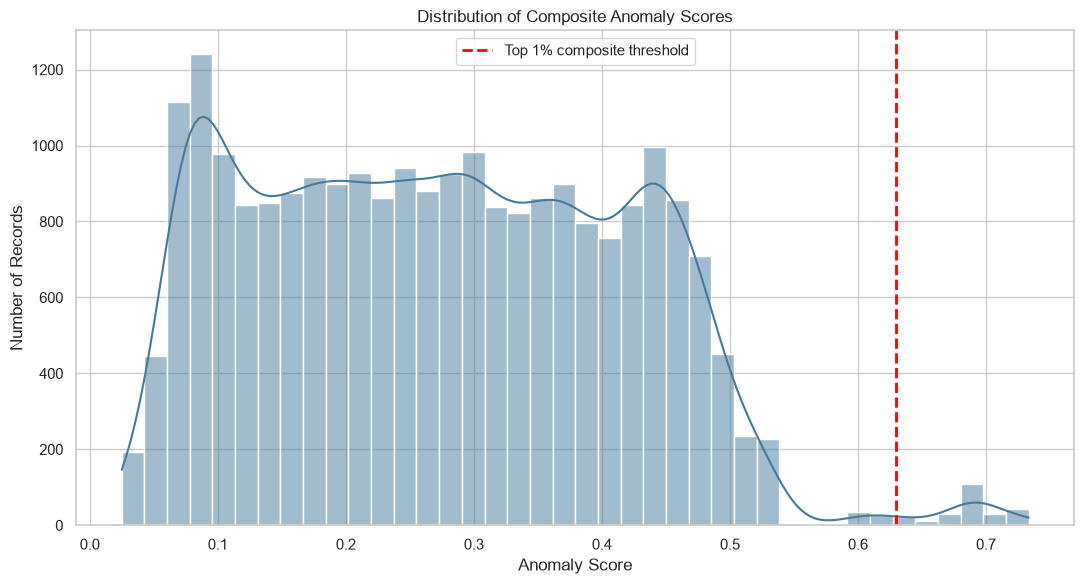

In [81]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=analysis_df,
    x="Anomaly Score",
    bins=40,
    kde=True,
    color="#457B9D"
)

plt.axvline(
    composite_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=(
        "Top 1% composite threshold"
    )
)

plt.title("Distribution of Composite Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
segment_anomaly_report = (
    analysis_df
    .groupby(
        [
            "GMM Cluster",
            "Segment Name"
        ]
    )
    .agg(
        Total_Records=(
            "Final Anomaly",
            "size"
        ),
        Anomaly_Records=(
            "Final Anomaly",
            "sum"
        ),
        Average_Anomaly_Score=(
            "Anomaly Score",
            "mean"
        )
    )
    .reset_index()
)

segment_anomaly_report["Anomaly Rate (%)"] = (
    segment_anomaly_report[
        "Anomaly_Records"
    ]
    / segment_anomaly_report[
        "Total_Records"
    ]
    * 100
)

segment_anomaly_report.round(3)

,GMM Cluster,Segment Name,Total_Records,Anomaly_Records,Average_Anomaly_Score,Anomaly Rate (%)
0,1,Highly Satisfied Recommenders,8560,48,0.203,0.561
1,2,Dissatisfied Non-Recommenders,1632,77,0.356,4.718
2,3,Satisfied Recommenders,2467,5,0.316,0.203
3,4,Highly Satisfied Recommenders,845,13,0.355,1.538
4,5,Highly Satisfied Recommenders,6791,16,0.219,0.236
5,6,Dissatisfied Non-Recommenders,2469,221,0.479,8.951
6,7,Critical but Recommending,722,87,0.486,12.050


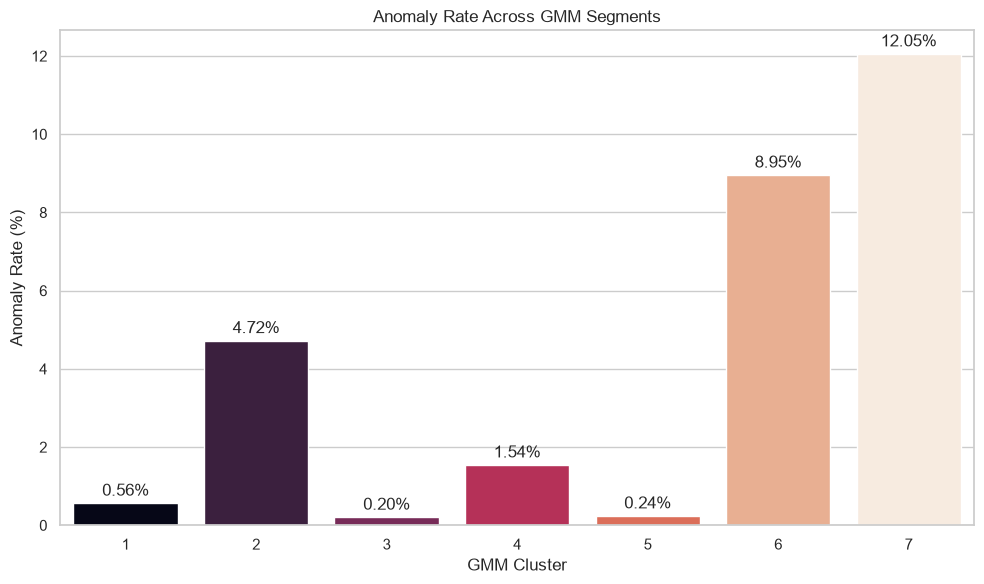

In [83]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_anomaly_report,
    x="GMM Cluster",
    y="Anomaly Rate (%)",
    hue="GMM Cluster",
    palette="rocket",
    legend=False
)

plt.title("Anomaly Rate Across GMM Segments")
plt.xlabel("GMM Cluster")
plt.ylabel("Anomaly Rate (%)")

for container in plt.gca().containers:
    plt.gca().bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

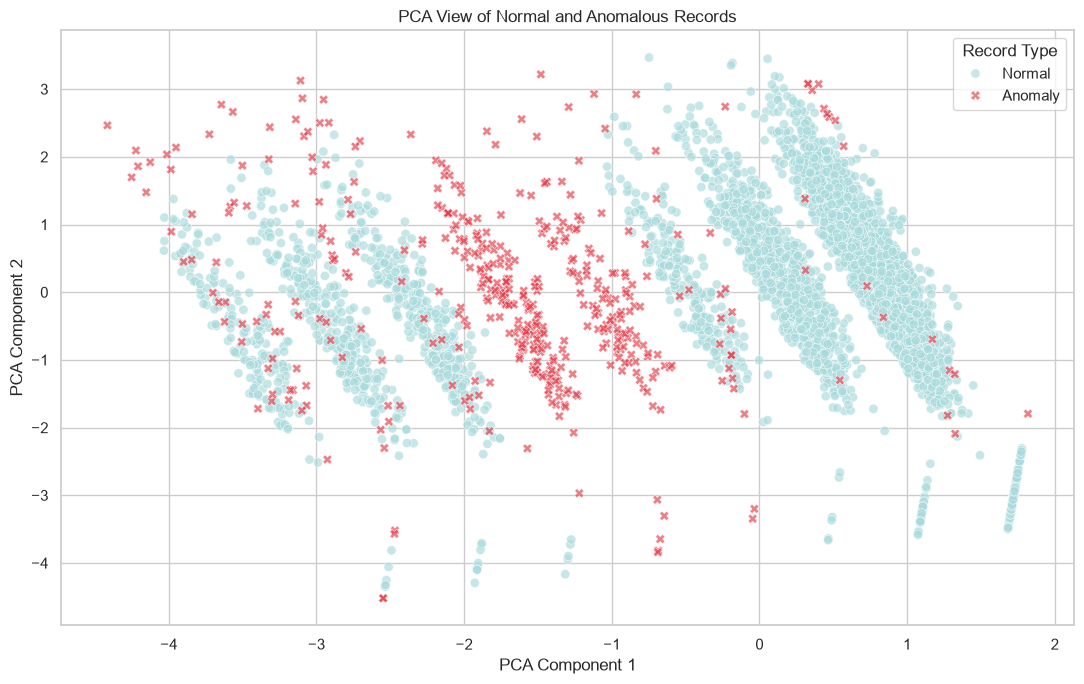

In [90]:
pca_anomaly_df = pd.DataFrame({
    "PCA Component 1": X_pca[:, 0],
    "PCA Component 2": X_pca[:, 1],
    "Final Anomaly": (
        analysis_df["Final Anomaly"]
        .map({
            0: "Normal",
            1: "Anomaly"
        })
        .to_numpy()
    )
})

normal_records = pca_anomaly_df[
    pca_anomaly_df["Final Anomaly"] == "Normal"
]

normal_sample = normal_records.sample(
    n=min(5000, len(normal_records)),
    random_state=42
)

all_anomalies = pca_anomaly_df[
    pca_anomaly_df["Final Anomaly"] == "Anomaly"
]

pca_anomaly_plot = pd.concat(
    [
        normal_sample,
        all_anomalies
    ],
    ignore_index=True
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_anomaly_plot,
    x="PCA Component 1",
    y="PCA Component 2",
    hue="Final Anomaly",
    style="Final Anomaly",
    palette={
        "Normal": "#A8DADC",
        "Anomaly": "#E63946"
    },
    alpha=0.65,
    s=45
)

plt.title("PCA View of Normal and Anomalous Records")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend(
    title="Record Type"
)

plt.tight_layout()
plt.show()

In [91]:
department_trend_report = (
    analysis_df
    .groupby("Department Name")
    .agg(
        Total_Reviews=("Rating", "size"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Recommendation_Rate=(
            "Recommended IND",
            "mean"
        ),
        Average_Positive_Feedback=(
            "Positive Feedback Count",
            "mean"
        ),
        Average_Review_Length=(
            "Review Length",
            "mean"
        ),
        Anomaly_Rate=(
            "Final Anomaly",
            "mean"
        ),
        Contradiction_Rate=(
            "Is Contradiction",
            "mean"
        )
    )
    .reset_index()
)

percentage_columns = [
    "Recommendation_Rate",
    "Anomaly_Rate",
    "Contradiction_Rate"
]

department_trend_report[
    percentage_columns
] *= 100

department_trend_report = (
    department_trend_report
    .sort_values(
        "Average_Rating",
        ascending=False
    )
)

department_trend_report.round(2)

,Department Name,Total_Reviews,Average_Rating,Median_Rating,Recommendation_Rate,Average_Positive_Feedback,Average_Review_Length,Anomaly_Rate,Contradiction_Rate
6,Unknown,14,5.00,5.0,100.00,0.50,31.21,0.00,0.00
0,Bottoms,3799,4.29,5.0,85.13,2.12,58.71,1.58,1.21
2,Intimate,1735,4.28,5.0,85.01,1.89,52.55,1.67,1.04
3,Jackets,1032,4.26,5.0,83.62,2.83,62.90,2.13,1.45
4,Tops,10468,4.17,5.0,81.52,2.43,55.17,1.88,1.13
1,Dresses,6319,4.15,5.0,80.82,3.09,62.93,2.47,1.65
5,Trend,119,3.82,4.0,73.95,3.37,68.53,2.52,1.68


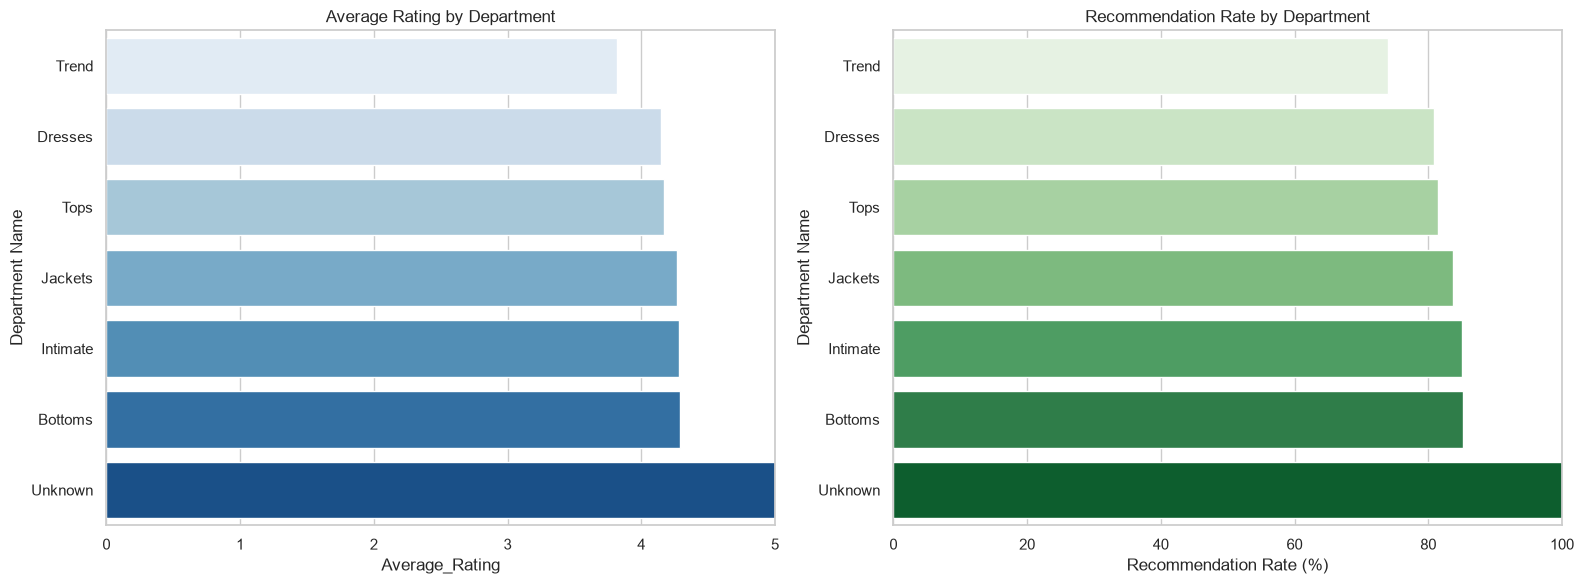

In [92]:
department_plot_data = (
    department_trend_report
    .sort_values("Average_Rating")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=department_plot_data,
    y="Department Name",
    x="Average_Rating",
    hue="Department Name",
    palette="Blues",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Average Rating by Department")
axes[0].set_xlim(0, 5)

sns.barplot(
    data=department_plot_data,
    y="Department Name",
    x="Recommendation_Rate",
    hue="Department Name",
    palette="Greens",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Recommendation Rate by Department"
)
axes[1].set_xlabel("Recommendation Rate (%)")
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [94]:
class_trend_report = (
    analysis_df
    .groupby("Class Name")
    .agg(
        Total_Reviews=("Rating", "size"),
        Average_Rating=("Rating", "mean"),
        Recommendation_Rate=(
            "Recommended IND",
            "mean"
        ),
        Average_Positive_Feedback=(
            "Positive Feedback Count",
            "mean"
        ),
        Anomaly_Rate=(
            "Final Anomaly",
            "mean"
        ),
        Contradiction_Rate=(
            "Is Contradiction",
            "mean"
        )
    )
    .reset_index()
)

class_trend_report[
    [
        "Recommendation_Rate",
        "Anomaly_Rate",
        "Contradiction_Rate"
    ]
] *= 100

reliable_class_report = (
    class_trend_report[
        class_trend_report["Total_Reviews"] >= 100
    ]
    .copy()
)

reliable_class_report = (
    reliable_class_report
    .sort_values(
        "Average_Rating",
        ascending=False
    )
)

reliable_class_report.round(2)

,Class Name,Total_Reviews,Average_Rating,Recommendation_Rate,Average_Positive_Feedback,Anomaly_Rate,Contradiction_Rate
9,Layering,146,4.38,88.36,1.32,2.74,2.05
7,Jeans,1147,4.36,88.14,1.76,1.31,0.87
11,Lounge,691,4.30,85.96,2.32,1.30,0.72
6,Jackets,704,4.30,84.52,2.83,1.42,0.71
16,Sleep,228,4.29,85.53,1.75,3.95,1.75
5,Intimates,154,4.28,85.71,0.78,1.30,0.65
10,Legwear,165,4.28,86.06,1.27,1.21,1.21
13,Pants,1388,4.27,83.29,2.40,1.87,1.59
4,Fine gauge,1100,4.26,83.73,2.01,1.36,0.91
14,Shorts,317,4.26,83.91,1.68,1.26,1.26


In [95]:
print("Top five classes by average rating:")

display(
    reliable_class_report[
        [
            "Class Name",
            "Total_Reviews",
            "Average_Rating",
            "Recommendation_Rate"
        ]
    ].head(5).round(2)
)

Top five classes by average rating:


,Class Name,Total_Reviews,Average_Rating,Recommendation_Rate
9,Layering,146,4.38,88.36
7,Jeans,1147,4.36,88.14
11,Lounge,691,4.30,85.96
6,Jackets,704,4.30,84.52
16,Sleep,228,4.29,85.53


In [96]:
print("Bottom five classes by average rating:")

display(
    reliable_class_report[
        [
            "Class Name",
            "Total_Reviews",
            "Average_Rating",
            "Recommendation_Rate"
        ]
    ].tail(5).round(2)
)

Bottom five classes by average rating:


,Class Name,Total_Reviews,Average_Rating,Recommendation_Rate
17,Sweaters,1428,4.18,80.04
8,Knits,4843,4.16,81.77
0,Blouses,3097,4.15,81.01
3,Dresses,6319,4.15,80.82
19,Trend,119,3.82,73.95


In [97]:
age_group_trend_report = (
    analysis_df
    .groupby(
        "Age Group",
        observed=False
    )
    .agg(
        Total_Reviews=("Rating", "size"),
        Average_Rating=("Rating", "mean"),
        Recommendation_Rate=(
            "Recommended IND",
            "mean"
        ),
        Average_Positive_Feedback=(
            "Positive Feedback Count",
            "mean"
        ),
        Average_Review_Length=(
            "Review Length",
            "mean"
        ),
        Anomaly_Rate=(
            "Final Anomaly",
            "mean"
        )
    )
    .reset_index()
)

age_group_trend_report[
    [
        "Recommendation_Rate",
        "Anomaly_Rate"
    ]
] *= 100

age_group_trend_report.round(2)

,Age Group,Total_Reviews,Average_Rating,Recommendation_Rate,Average_Positive_Feedback,Average_Review_Length,Anomaly_Rate
0,18-29,2931,4.20,81.75,2.01,57.48,2.01
1,30-39,7702,4.17,81.36,2.50,57.67,1.57
2,40-49,6127,4.16,81.25,2.43,57.92,1.68
3,50-59,3948,4.24,83.76,2.91,57.46,2.18
4,60-69,2305,4.29,85.60,2.93,61.21,2.08
5,70+,473,4.25,83.30,2.65,57.99,10.57


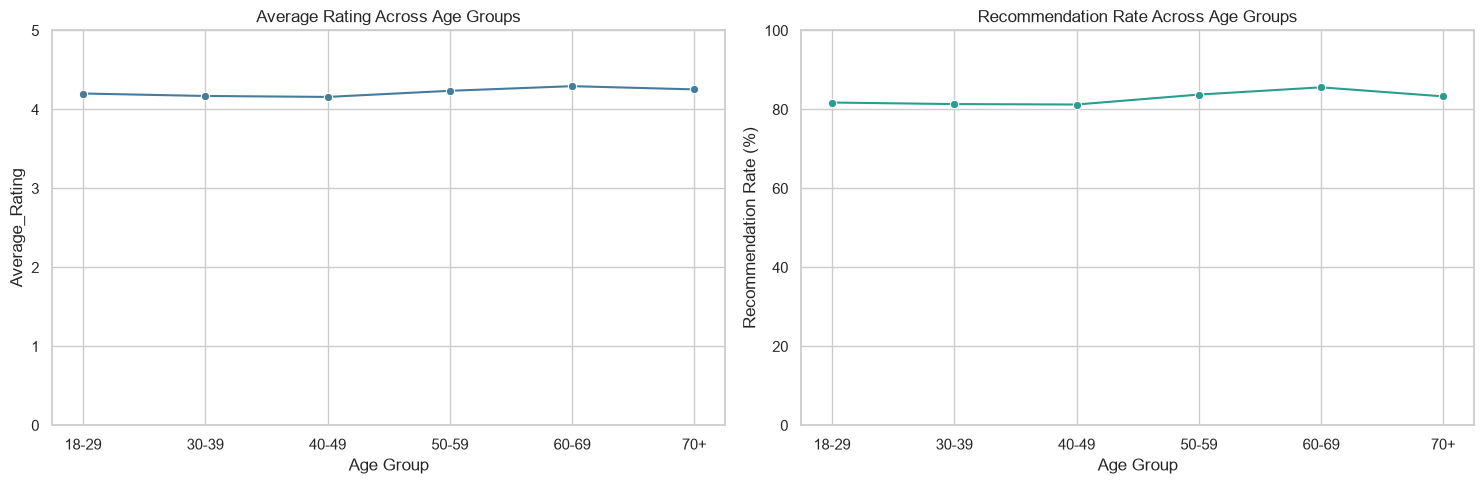

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=age_group_trend_report,
    x="Age Group",
    y="Average_Rating",
    marker="o",
    color="#457B9D",
    ax=axes[0]
)

axes[0].set_title("Average Rating Across Age Groups")
axes[0].set_ylim(0, 5)

sns.lineplot(
    data=age_group_trend_report,
    x="Age Group",
    y="Recommendation_Rate",
    marker="o",
    color="#2A9D8F",
    ax=axes[1]
)

axes[1].set_title(
    "Recommendation Rate Across Age Groups"
)
axes[1].set_ylabel("Recommendation Rate (%)")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [99]:
department_rating_groups = [
    group["Rating"].dropna().to_numpy()
    for _, group in analysis_df.groupby(
        "Department Name"
    )
    if len(group) > 1
]

kruskal_statistic, kruskal_p_value = kruskal(
    *department_rating_groups
)

print(
    "Kruskal-Wallis statistic:",
    round(kruskal_statistic, 4)
)

print(
    "P-value:",
    kruskal_p_value
)

if kruskal_p_value < 0.05:
    print(
        "Conclusion: Department-wise rating "
        "distributions are significantly different."
    )
else:
    print(
        "Conclusion: Significant department-wise "
        "rating difference was not detected."
    )

Kruskal-Wallis statistic: 88.3306
P-value: 6.730523595778053e-17
Conclusion: Department-wise rating distributions are significantly different.


In [100]:
department_recommendation_table = pd.crosstab(
    analysis_df["Department Name"],
    analysis_df["Recommended IND"]
)

(
    department_chi2,
    department_p_value,
    department_dof,
    department_expected
) = chi2_contingency(
    department_recommendation_table
)

department_cramers_v = calculate_cramers_v(
    department_recommendation_table
)

print(
    "Chi-square statistic:",
    round(department_chi2, 4)
)

print(
    "Degrees of freedom:",
    department_dof
)

print(
    "P-value:",
    department_p_value
)

print(
    "Cramér's V:",
    round(department_cramers_v, 4)
)

if department_p_value < 0.05:
    print(
        "Conclusion: Department and recommendation "
        "are statistically associated."
    )
else:
    print(
        "Conclusion: Significant association between "
        "department and recommendation was not detected."
    )

Chi-square statistic: 53.2928
Degrees of freedom: 6
P-value: 1.0242849041350807e-09
Cramér's V: 0.0449
Conclusion: Department and recommendation are statistically associated.


In [101]:
correlation_pairs = [
    (
        "Positive Feedback Count",
        "Rating"
    ),
    (
        "Positive Feedback Count",
        "Recommended IND"
    ),
    (
        "Review Length",
        "Rating"
    ),
    (
        "Review Length",
        "Recommended IND"
    )
]

correlation_records = []

for first_column, second_column in correlation_pairs:
    correlation, p_value = spearmanr(
        analysis_df[first_column],
        analysis_df[second_column]
    )

    correlation_records.append({
        "Variable 1": first_column,
        "Variable 2": second_column,
        "Spearman Correlation": correlation,
        "P-value": p_value
    })

engagement_correlation_report = (
    pd.DataFrame(correlation_records)
    .round(4)
)

engagement_correlation_report

,Variable 1,Variable 2,Spearman Correlation,P-value
0,Positive Feedback Count,Rating,-0.0683,0.0
1,Positive Feedback Count,Recommended IND,-0.0809,0.0
2,Review Length,Rating,-0.0923,0.0
3,Review Length,Recommended IND,-0.0423,0.0


In [102]:
department_anomaly_report = (
    analysis_df
    .groupby("Department Name")
    .agg(
        Total_Records=(
            "Final Anomaly",
            "size"
        ),
        Anomalies=(
            "Final Anomaly",
            "sum"
        ),
        Contradictions=(
            "Is Contradiction",
            "sum"
        )
    )
    .reset_index()
)

department_anomaly_report["Anomaly Rate (%)"] = (
    department_anomaly_report["Anomalies"]
    / department_anomaly_report["Total_Records"]
    * 100
)

department_anomaly_report[
    "Contradiction Rate (%)"
] = (
    department_anomaly_report[
        "Contradictions"
    ]
    / department_anomaly_report[
        "Total_Records"
    ]
    * 100
)

department_anomaly_report = (
    department_anomaly_report
    .sort_values(
        "Anomaly Rate (%)",
        ascending=False
    )
)

department_anomaly_report.round(3)

,Department Name,Total_Records,Anomalies,Contradictions,Anomaly Rate (%),Contradiction Rate (%)
5,Trend,119,3,2,2.521,1.681
1,Dresses,6319,156,104,2.469,1.646
3,Jackets,1032,22,15,2.132,1.453
4,Tops,10468,197,118,1.882,1.127
2,Intimate,1735,29,18,1.671,1.037
0,Bottoms,3799,60,46,1.579,1.211
6,Unknown,14,0,0,0.000,0.000


In [103]:
highest_rating_department = (
    department_trend_report
    .sort_values(
        "Average_Rating",
        ascending=False
    )
    .iloc[0]
)

lowest_rating_department = (
    department_trend_report
    .sort_values(
        "Average_Rating",
        ascending=True
    )
    .iloc[0]
)

highest_recommendation_department = (
    department_trend_report
    .sort_values(
        "Recommendation_Rate",
        ascending=False
    )
    .iloc[0]
)

highest_anomaly_department = (
    department_trend_report
    .sort_values(
        "Anomaly_Rate",
        ascending=False
    )
    .iloc[0]
)

print("KEY DEEPER TREND INSIGHTS")
print("-" * 50)

print(
    "Highest-rated department:",
    highest_rating_department[
        "Department Name"
    ],
    "| Average rating:",
    round(
        highest_rating_department[
            "Average_Rating"
        ],
        2
    )
)

print(
    "Lowest-rated department:",
    lowest_rating_department[
        "Department Name"
    ],
    "| Average rating:",
    round(
        lowest_rating_department[
            "Average_Rating"
        ],
        2
    )
)

print(
    "Highest recommendation department:",
    highest_recommendation_department[
        "Department Name"
    ],
    "| Recommendation rate:",
    round(
        highest_recommendation_department[
            "Recommendation_Rate"
        ],
        2
    ),
    "%"
)

print(
    "Highest anomaly-rate department:",
    highest_anomaly_department[
        "Department Name"
    ],
    "| Anomaly rate:",
    round(
        highest_anomaly_department[
            "Anomaly_Rate"
        ],
        2
    ),
    "%"
)

print(
    "Total GMM segments:",
    analysis_df["GMM Cluster"].nunique()
)

print(
    "Total anomalies:",
    analysis_df["Final Anomaly"].sum()
)

print(
    "Overall anomaly rate:",
    round(
        analysis_df["Final Anomaly"].mean()
        * 100,
        2
    ),
    "%"
)

KEY DEEPER TREND INSIGHTS
--------------------------------------------------
Highest-rated department: Unknown | Average rating: 5.0
Lowest-rated department: Trend | Average rating: 3.82
Highest recommendation department: Unknown | Recommendation rate: 100.0 %
Highest anomaly-rate department: Trend | Anomaly rate: 2.52 %
Total GMM segments: 7
Total anomalies: 467
Overall anomaly rate: 1.99 %


In [104]:
statistical_test_report = pd.DataFrame({
    "Statistical Test": [
        "Rating vs Recommendation — Chi-square",
        "Rating vs Recommendation — Cramér's V",
        "Rating vs Recommendation — Spearman",
        "Department Ratings — Kruskal-Wallis",
        "Department vs Recommendation — Chi-square",
        "Department vs Recommendation — Cramér's V"
    ],
    "Statistic": [
        chi_square,
        cramers_v,
        spearman_correlation,
        kruskal_statistic,
        department_chi2,
        department_cramers_v
    ],
    "P-value": [
        p_value,
        np.nan,
        spearman_p_value,
        kruskal_p_value,
        department_p_value,
        np.nan
    ]
})

statistical_test_report.round(6)

,Statistical Test,Statistic,P-value
0,Rating vs Recommendation — Chi-square,16722.503172,0.0
1,Rating vs Recommendation — Cramér's V,0.843730,NaN
2,Rating vs Recommendation — Spearman,0.693509,0.0
3,Department Ratings — Kruskal-Wallis,88.330589,0.0
4,Department vs Recommendation — Chi-square,53.292848,0.0
5,Department vs Recommendation — Cramér's V,0.044875,NaN


In [105]:
final_segmented_df = analysis_df.copy()

rounding_columns = [
    "Cluster Confidence",
    "Cluster Uncertainty",
    "GMM Log Density",
    "Density Rarity Score",
    "Anomaly Score"
]

for column in rounding_columns:
    if column in final_segmented_df.columns:
        final_segmented_df[column] = (
            final_segmented_df[column]
            .round(6)
        )

print(
    "Final segmented dataset shape:",
    final_segmented_df.shape
)

final_segmented_df.head()

Final segmented dataset shape: (23486, 29)


,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review Text,Review Length,...,Density Anomaly,Low Confidence Anomaly,Age_Extreme,Positive_Feedback_Count_Extreme,Review_Length_Extreme,Extreme Feature Count,Density Rarity Score,Anomaly Score,Final Anomaly,Anomaly Type
0,767,33,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and comf...,8,...,0,0,0,0,0,0,0.809929,0.407106,0,Normal
1,1080,34,5,1,4,General,Dresses,Dresses,Love this dress! it's sooo pretty. i happene...,62,...,0,0,0,0,0,0,0.230989,0.115494,0,Normal
2,1077,60,3,0,0,General,Dresses,Dresses,I had such high hopes for this dress and reall...,98,...,0,0,0,0,0,0,0.802989,0.401678,0,Normal
3,1049,50,5,1,0,General Petite,Bottoms,Pants,"I love, love, love this jumpsuit. it's fun, fl...",22,...,0,0,0,0,0,0,0.200460,0.150215,0,Normal
4,847,47,5,1,6,General,Tops,Blouses,This shirt is very flattering to all due to th...,36,...,0,0,0,0,0,0,0.373116,0.186558,0,Normal


In [106]:
final_segmented_df.to_csv(
    "womens_clothing_segmented_analysis.csv",
    index=False
)

anomaly_df.to_csv(
    "womens_clothing_anomaly_report.csv",
    index=False
)

cluster_profile.to_csv(
    "gmm_cluster_profile.csv",
    index=False
)

gmm_selection_report.to_csv(
    "gmm_model_selection_report.csv",
    index=False
)

department_trend_report.to_csv(
    "department_trend_report.csv",
    index=False
)

reliable_class_report.to_csv(
    "class_trend_report.csv",
    index=False
)

age_group_trend_report.to_csv(
    "age_group_trend_report.csv",
    index=False
)

statistical_test_report.to_csv(
    "statistical_test_report.csv",
    index=False
)

engagement_correlation_report.to_csv(
    "engagement_correlation_report.csv",
    index=False
)

print("All CSV reports exported successfully.")

All CSV reports exported successfully.


In [108]:
gmm_model_bundle = {
    "model": best_gmm,
    "scaler": scaler,
    "feature_names": gmm_features,
    "number_of_clusters": best_number_of_clusters,
    "covariance_type": best_covariance_type,
    "density_threshold": density_threshold,
    "composite_threshold": composite_threshold
}

joblib.dump(
    gmm_model_bundle,
    "womens_clothing_gmm_model.joblib"
)

print("GMM model bundle saved successfully.")

GMM model bundle saved successfully.


In [109]:
exported_files = [
    "womens_clothing_segmented_analysis.csv",
    "womens_clothing_anomaly_report.csv",
    "gmm_cluster_profile.csv",
    "gmm_model_selection_report.csv",
    "department_trend_report.csv",
    "class_trend_report.csv",
    "age_group_trend_report.csv",
    "statistical_test_report.csv",
    "engagement_correlation_report.csv",
    "womens_clothing_complete_analysis.xlsx",
    "womens_clothing_gmm_model.joblib"
]

verification_records = []

for file_name in exported_files:
    file_exists = os.path.exists(file_name)

    verification_records.append({
        "File": file_name,
        "Created": file_exists,
        "Size KB": (
            round(
                os.path.getsize(file_name) / 1024,
                2
            )
            if file_exists
            else 0
        )
    })

file_verification_report = pd.DataFrame(
    verification_records
)

file_verification_report

,File,Created,Size KB
0,womens_clothing_segmented_analysis.csv,True,10893.13
1,womens_clothing_anomaly_report.csv,True,236.72
2,gmm_cluster_profile.csv,True,1.26
3,gmm_model_selection_report.csv,True,1.34
4,department_trend_report.csv,True,0.96
5,class_trend_report.csv,True,1.95
6,age_group_trend_report.csv,True,0.71
7,statistical_test_report.csv,True,0.46
8,engagement_correlation_report.csv,True,0.22
9,womens_clothing_complete_analysis.xlsx,True,6439.48


In [110]:
overall_average_rating = (
    analysis_df["Rating"].mean()
)

overall_recommendation_rate = (
    analysis_df["Recommended IND"].mean()
    * 100
)

positive_rating_rate = (
    analysis_df["Rating"]
    .isin([4, 5])
    .mean()
    * 100
)

overall_anomaly_rate = (
    analysis_df["Final Anomaly"].mean()
    * 100
)

overall_contradiction_rate = (
    analysis_df["Is Contradiction"].mean()
    * 100
)

final_summary = f"""
WOMEN'S CLOTHING: TRENDS AND ANALYSIS
FINAL ANALYTICAL SUMMARY
--------------------------------------------------

Dataset:
- Total records: {len(analysis_df):,}
- Average rating: {overall_average_rating:.2f}
- Positive rating rate: {positive_rating_rate:.2f}%
- Recommendation rate: {overall_recommendation_rate:.2f}%

Rating and Recommendation Relationship:
- Chi-square statistic: {chi_square:.4f}
- Chi-square p-value: {p_value}
- Cramer's V: {cramers_v:.4f}
- Spearman correlation: {spearman_correlation:.4f}

Gaussian Mixture Modeling:
- Selected clusters: {best_number_of_clusters}
- Covariance type: {best_covariance_type}
- Selected model BIC: {best_model_row["BIC"]:.2f}
- Selected model AIC: {best_model_row["AIC"]:.2f}

Anomaly Analysis:
- Total anomalies: {analysis_df["Final Anomaly"].sum():,}
- Overall anomaly rate: {overall_anomaly_rate:.2f}%
- Rating-recommendation contradictions:
  {analysis_df["Is Contradiction"].sum():,}
- Contradiction rate: {overall_contradiction_rate:.2f}%

Department Insights:
- Highest-rated department:
  {highest_rating_department["Department Name"]}
- Lowest-rated department:
  {lowest_rating_department["Department Name"]}
- Highest recommendation department:
  {highest_recommendation_department["Department Name"]}
- Highest anomaly-rate department:
  {highest_anomaly_department["Department Name"]}

Final Conclusion:
Ratings and recommendations have a statistically significant
and strong positive association. Most reviews are positive and
most customers recommend the products. Gaussian mixture modeling
identified distinct probabilistic customer-review segments using
rating, recommendation, age, feedback engagement and review
length. Anomaly detection revealed rare model patterns,
rating-recommendation contradictions, uncertain assignments and
multiple numerical extremes. Department, class and age-group
analysis provided deeper product and customer trend insights.
"""

print(final_summary)


WOMEN'S CLOTHING: TRENDS AND ANALYSIS
FINAL ANALYTICAL SUMMARY
--------------------------------------------------

Dataset:
- Total records: 23,486
- Average rating: 4.20
- Positive rating rate: 77.53%
- Recommendation rate: 82.24%

Rating and Recommendation Relationship:
- Chi-square statistic: 16722.5032
- Chi-square p-value: 8.991374791404909e-11
- Cramer's V: 0.8437
- Spearman correlation: 0.6935

Gaussian Mixture Modeling:
- Selected clusters: 7
- Covariance type: full
- Selected model BIC: -183289.48
- Selected model AIC: -184466.84

Anomaly Analysis:
- Total anomalies: 467
- Overall anomaly rate: 1.99%
- Rating-recommendation contradictions:
  303
- Contradiction rate: 1.29%

Department Insights:
- Highest-rated department:
  Unknown
- Lowest-rated department:
  Trend
- Highest recommendation department:
  Unknown
- Highest anomaly-rate department:
  Trend

Final Conclusion:
Ratings and recommendations have a statistically significant
and strong positive association. Most revie

In [111]:
with open(
    "womens_clothing_final_summary.txt",
    "w",
    encoding="utf-8"
) as summary_file:
    summary_file.write(final_summary)

print("Final summary file exported.")

Final summary file exported.
